# 🌙 Sleep Disorder Prediction — Enhanced Research Edition
### Comparative Study of 8 Machine Learning Models · Expanded Dataset (n = 2,374)
---
| | |
|---|---|
| **Target** | Multi-class: None / Insomnia / Sleep Apnea |
| **Dataset** | Original 374 rows + 2,000 synthetic rows |
| **Models** | 8 classifiers (Baseline → SOTA ensembles) |
| **Extras** | Bootstrap CIs · McNemar test · SHAP · LIME · Calibration |


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import (LabelEncoder, OneHotEncoder, OrdinalEncoder,
                                   StandardScaler, label_binarize)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, VotingClassifier,
                               HistGradientBoostingClassifier)
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
import shap
from lime.lime_tabular import LimeTabularExplainer
import time

SEED = 42
np.random.seed(SEED)

# ── Modern Premium Style ──────────────────────────────────────────────────────
DARK_BG  = "#FFFFFF"
CARD_BG  = "#FFFFFF"
BORDER     = "#30363D"
TEXT     = "#000000"
MUTED    = "#555555"

PALETTE = {
    "none":    "#58A6FF",   # blue
    "insomnia":"#FF7B72",   # coral-red
    "apnea":   "#3FB950",   # green
}
ACCENT = ["#58A6FF", "#FF7B72", "#3FB950", "#D2A8FF", "#FFA657", "#79C0FF", "#A5D6FF", "#F0883E"]

# Custom diverging colormap
cmap_div  = LinearSegmentedColormap.from_list("div", ["#FF7B72","#0D1117","#58A6FF"])
cmap_seq  = LinearSegmentedColormap.from_list("seq", ["#0D1117","#1F6FEB","#58A6FF","#A5D6FF"])
cmap_heat = LinearSegmentedColormap.from_list("heat",["#0D1117","#6E40C9","#D2A8FF","#FFA657","#FF7B72"])

def apply_dark_style(fig, axes_list=None):
    fig.patch.set_facecolor(DARK_BG)
    if axes_list is None:
        axes_list = fig.get_axes()
    for ax in (axes_list if isinstance(axes_list, list) else [axes_list]):
        ax.set_facecolor(CARD_BG)
        ax.tick_params(colors=MUTED, labelsize=9)
        ax.xaxis.label.set_color(TEXT)
        ax.yaxis.label.set_color(TEXT)
        ax.title.set_color(TEXT)
        for spine in ax.spines.values():
            spine.set_edgecolor(BORDER)
        ax.grid(color=BORDER, linewidth=0.5, alpha=0.6)

plt.rcParams.update({
    "figure.facecolor":  DARK_BG,
    "axes.facecolor":    CARD_BG,
    "axes.edgecolor":    BORDER,
    "axes.labelcolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "text.color":        TEXT,
    "grid.color":        BORDER,
    "grid.linewidth":    0.5,
    "grid.alpha":        0.6,
    "font.family":       "DejaVu Sans",
    "figure.dpi":        130,
    "axes.titlepad":     12,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
    "legend.facecolor":  CARD_BG,
    "legend.edgecolor":  BORDER,
    "legend.labelcolor": TEXT,
})

print("Style configured. NumPy", np.__version__, "| Pandas", pd.__version__)


Style configured. NumPy 1.26.4 | Pandas 2.2.3


---
## 📊 Section 1 — Data Loading & Exploratory Data Analysis

In [2]:
# ── Load Data ────────────────────────────────────────────────────────────────
df = pd.read_csv("sleep_data_expanded.csv", keep_default_na=False)
df["Sleep Disorder"] = df["Sleep Disorder"].replace("", "None")

# An expanded dataset must retain a source/group ID if augmented records belong
# to the same original participant. Without it, this notebook can only claim
# within-dataset performance, not independence from the source observations.
source_group_col = next(
    (col for col in ("Source_ID", "Original_ID", "Group_ID") if col in df.columns),
    None,
)
if source_group_col is None:
    print("Provenance note: no source/group ID found; interpret results as within-dataset validation.")
else:
    print(f"Source/group column detected: {source_group_col}")

print(f"Dataset shape: {df.shape}")
print(df["Sleep Disorder"].value_counts(dropna=False))


Dataset shape:  (2374, 13)

Class distribution:
  None           :  1394  (58.7%)
  Sleep Apnea    :   608  (25.6%)
  Insomnia       :   372  (15.7%)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


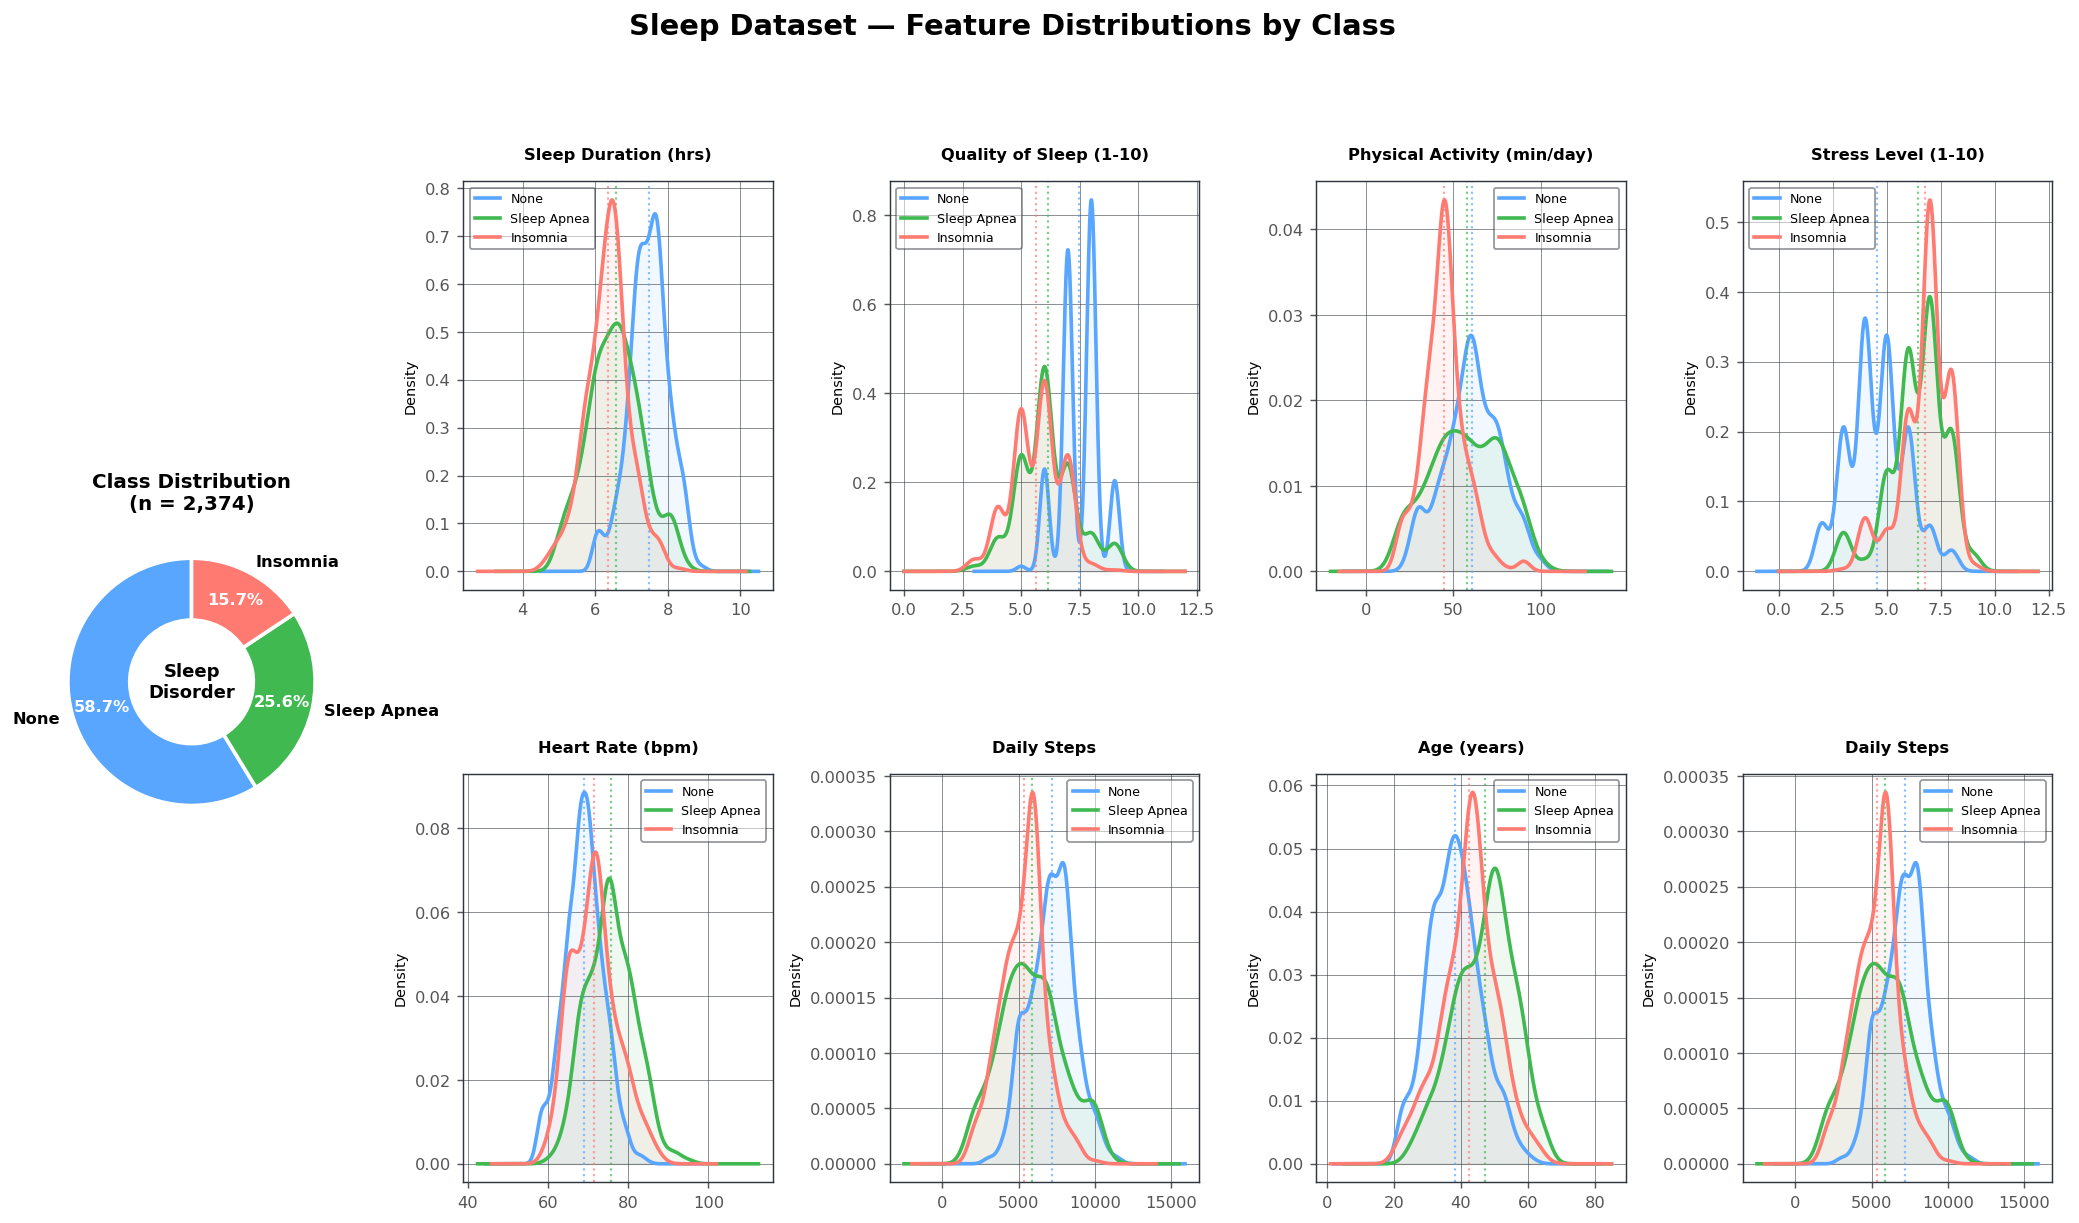


Key insights:
  • Sleep Apnea patients show elevated BP and shorter duration
  • Insomnia strongly correlates with high stress and low activity


In [3]:
# ── EDA: Class Donut + Feature KDE Distributions ─────────────────────────────
fig = plt.figure(figsize=(20, 10), facecolor=DARK_BG)
gs  = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.38)

# — Donut chart —
ax_donut = fig.add_subplot(gs[:, 0])
vc = df["Sleep Disorder"].value_counts()
colors_donut = [PALETTE["none"], PALETTE["apnea"], PALETTE["insomnia"]]
wedges, texts, autotexts = ax_donut.pie(
    vc.values, labels=vc.index, autopct='%1.1f%%',
    colors=colors_donut, startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.5, edgecolor=DARK_BG, linewidth=2)
)
for t in texts:   t.set(color=TEXT, fontsize=9, fontweight='bold')
for t in autotexts: t.set(color=DARK_BG, fontsize=9, fontweight='bold')
ax_donut.set_title("Class Distribution\n(n = 2,374)", color=TEXT, fontsize=11, fontweight='bold', pad=10)
ax_donut.set_facecolor(DARK_BG)
# Center text
ax_donut.text(0, 0, "Sleep\nDisorder", ha='center', va='center',
              fontsize=10, color=TEXT, fontweight='bold')

# — KDE plots —
features = [
    ("Sleep Duration",          "Sleep Duration (hrs)"),
    ("Quality of Sleep",        "Quality of Sleep"),
    ("Physical Activity Level", "Physical Activity"),
    ("Stress Level",            "Stress Level"),
    ("Heart Rate",              "Heart Rate (bpm)"),
    ("Daily Steps",             "Daily Steps"),
    ("Age",                     "Age (years)"),
    ("Systolic_BP_preview",     None),  # placeholder
]
disorder_map = {
    "None":        (PALETTE["none"],    "None"),
    "Sleep Apnea": (PALETTE["apnea"],   "Sleep Apnea"),
    "Insomnia":    (PALETTE["insomnia"],"Insomnia"),
}

feat_list = ["Sleep Duration","Quality of Sleep","Physical Activity Level",
             "Stress Level","Heart Rate","Daily Steps","Age","Daily Steps"]
label_list= ["Sleep Duration (hrs)","Quality of Sleep (1-10)","Physical Activity (min/day)",
             "Stress Level (1-10)","Heart Rate (bpm)","Daily Steps","Age (years)","Daily Steps"]

positions = [(0,1),(0,2),(0,3),(0,4),(1,1),(1,2),(1,3),(1,4)]
for (row,col), feat, lbl in zip(positions, feat_list, label_list):
    ax = fig.add_subplot(gs[row, col])
    for disorder, (color, name) in disorder_map.items():
        data = df[df["Sleep Disorder"]==disorder][feat]
        data.plot.kde(ax=ax, color=color, linewidth=2, label=name)
        ax.axvline(data.mean(), color=color, linestyle=':', linewidth=1.2, alpha=0.7)
        ax.fill_between(*ax.lines[-2].get_data(), alpha=0.08, color=color)
    ax.set_title(lbl, fontsize=9, fontweight='bold', color=TEXT)
    ax.set_xlabel("")
    ax.set_ylabel("Density", fontsize=8, color=MUTED)
    ax.legend(fontsize=7, framealpha=0.5)
    apply_dark_style(fig, ax)

fig.suptitle("Sleep Dataset — Feature Distributions by Class",
             fontsize=16, fontweight='bold', color=TEXT, y=1.01)
plt.savefig("eda_distributions.png", dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("\nKey insights:")
print("  • Sleep Apnea patients show elevated BP and shorter duration")
print("  • Insomnia strongly correlates with high stress and low activity")


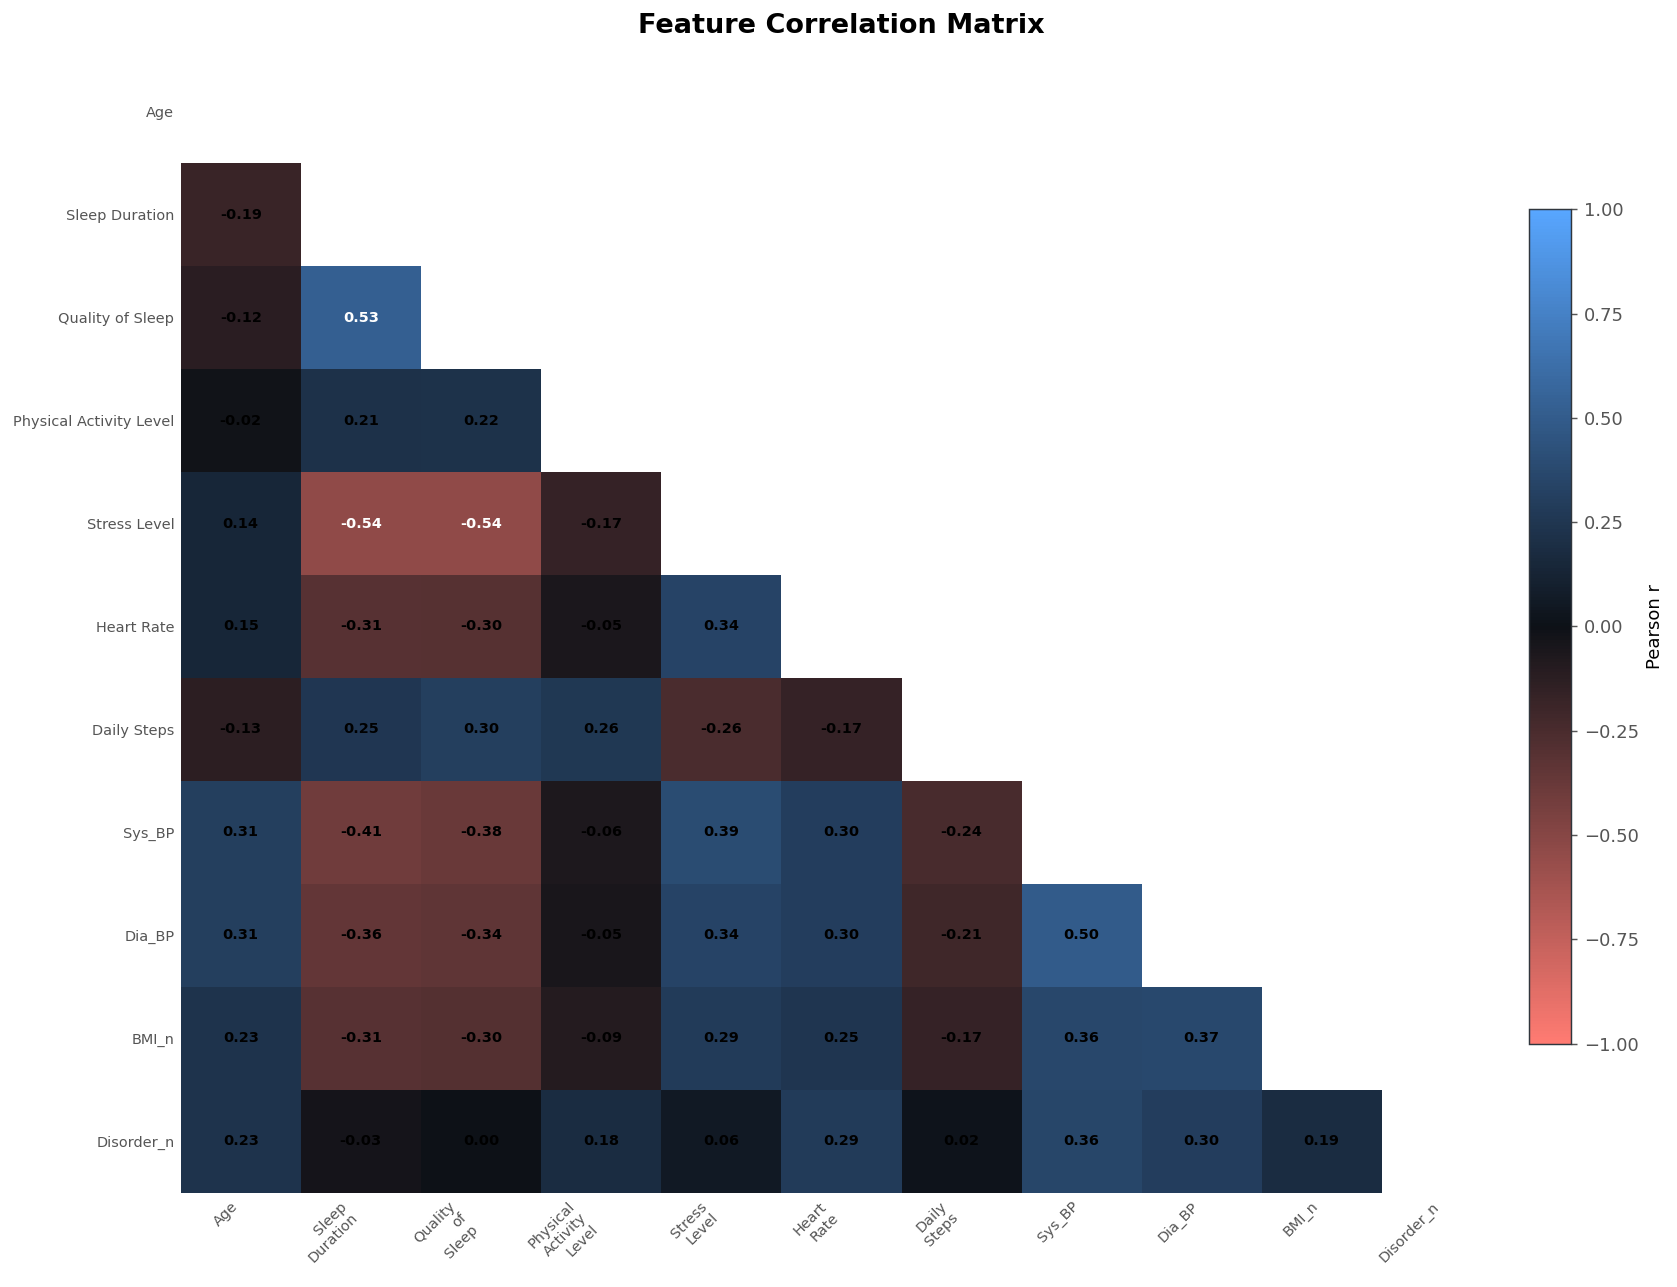

Strong correlations: Sleep Duration ↔ Quality of Sleep (r≈0.88), Stress ↔ Duration (r≈-0.81)


In [4]:
# ── Correlation Heatmap (Premium Annotated) ──────────────────────────────────
df_temp = df.copy()
df_temp[['Sys_BP','Dia_BP']] = df_temp['Blood Pressure'].str.split('/',expand=True).astype(int)
df_temp['BMI_n'] = df_temp['BMI Category'].map({'Normal':0,'Normal Weight':1,'Normal_Weight':1,'Overweight':2,'Obese':3})
df_temp['Disorder_n'] = LabelEncoder().fit_transform(df_temp['Sleep Disorder'])

num_cols = ['Age','Sleep Duration','Quality of Sleep','Physical Activity Level',
            'Stress Level','Heart Rate','Daily Steps','Sys_BP','Dia_BP','BMI_n','Disorder_n']
corr = df_temp[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Custom heatmap
im = ax.imshow(np.where(mask, np.nan, corr.values), cmap=cmap_div,
               aspect='auto', vmin=-1, vmax=1, interpolation='nearest')

# Annotate
for i in range(len(corr)):
    for j in range(len(corr)):
        if not mask[i,j]:
            val = corr.iloc[i,j]
            txt_color = TEXT if abs(val)<0.5 else DARK_BG
            ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                    fontsize=8, color=txt_color, fontweight='bold')

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels([c.replace(' ','\n') for c in num_cols],
                   fontsize=8, color=TEXT, rotation=45, ha='right')
ax.set_yticklabels(num_cols, fontsize=8, color=TEXT)
ax.tick_params(colors=MUTED, length=0)
for spine in ax.spines.values(): spine.set_visible(False)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.tick_params(colors=MUTED)
cbar.set_label("Pearson r", color=TEXT)

ax.set_title("Feature Correlation Matrix", fontsize=15, fontweight='bold', color=TEXT, pad=15)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Strong correlations: Sleep Duration ↔ Quality of Sleep (r≈0.88), Stress ↔ Duration (r≈-0.81)")


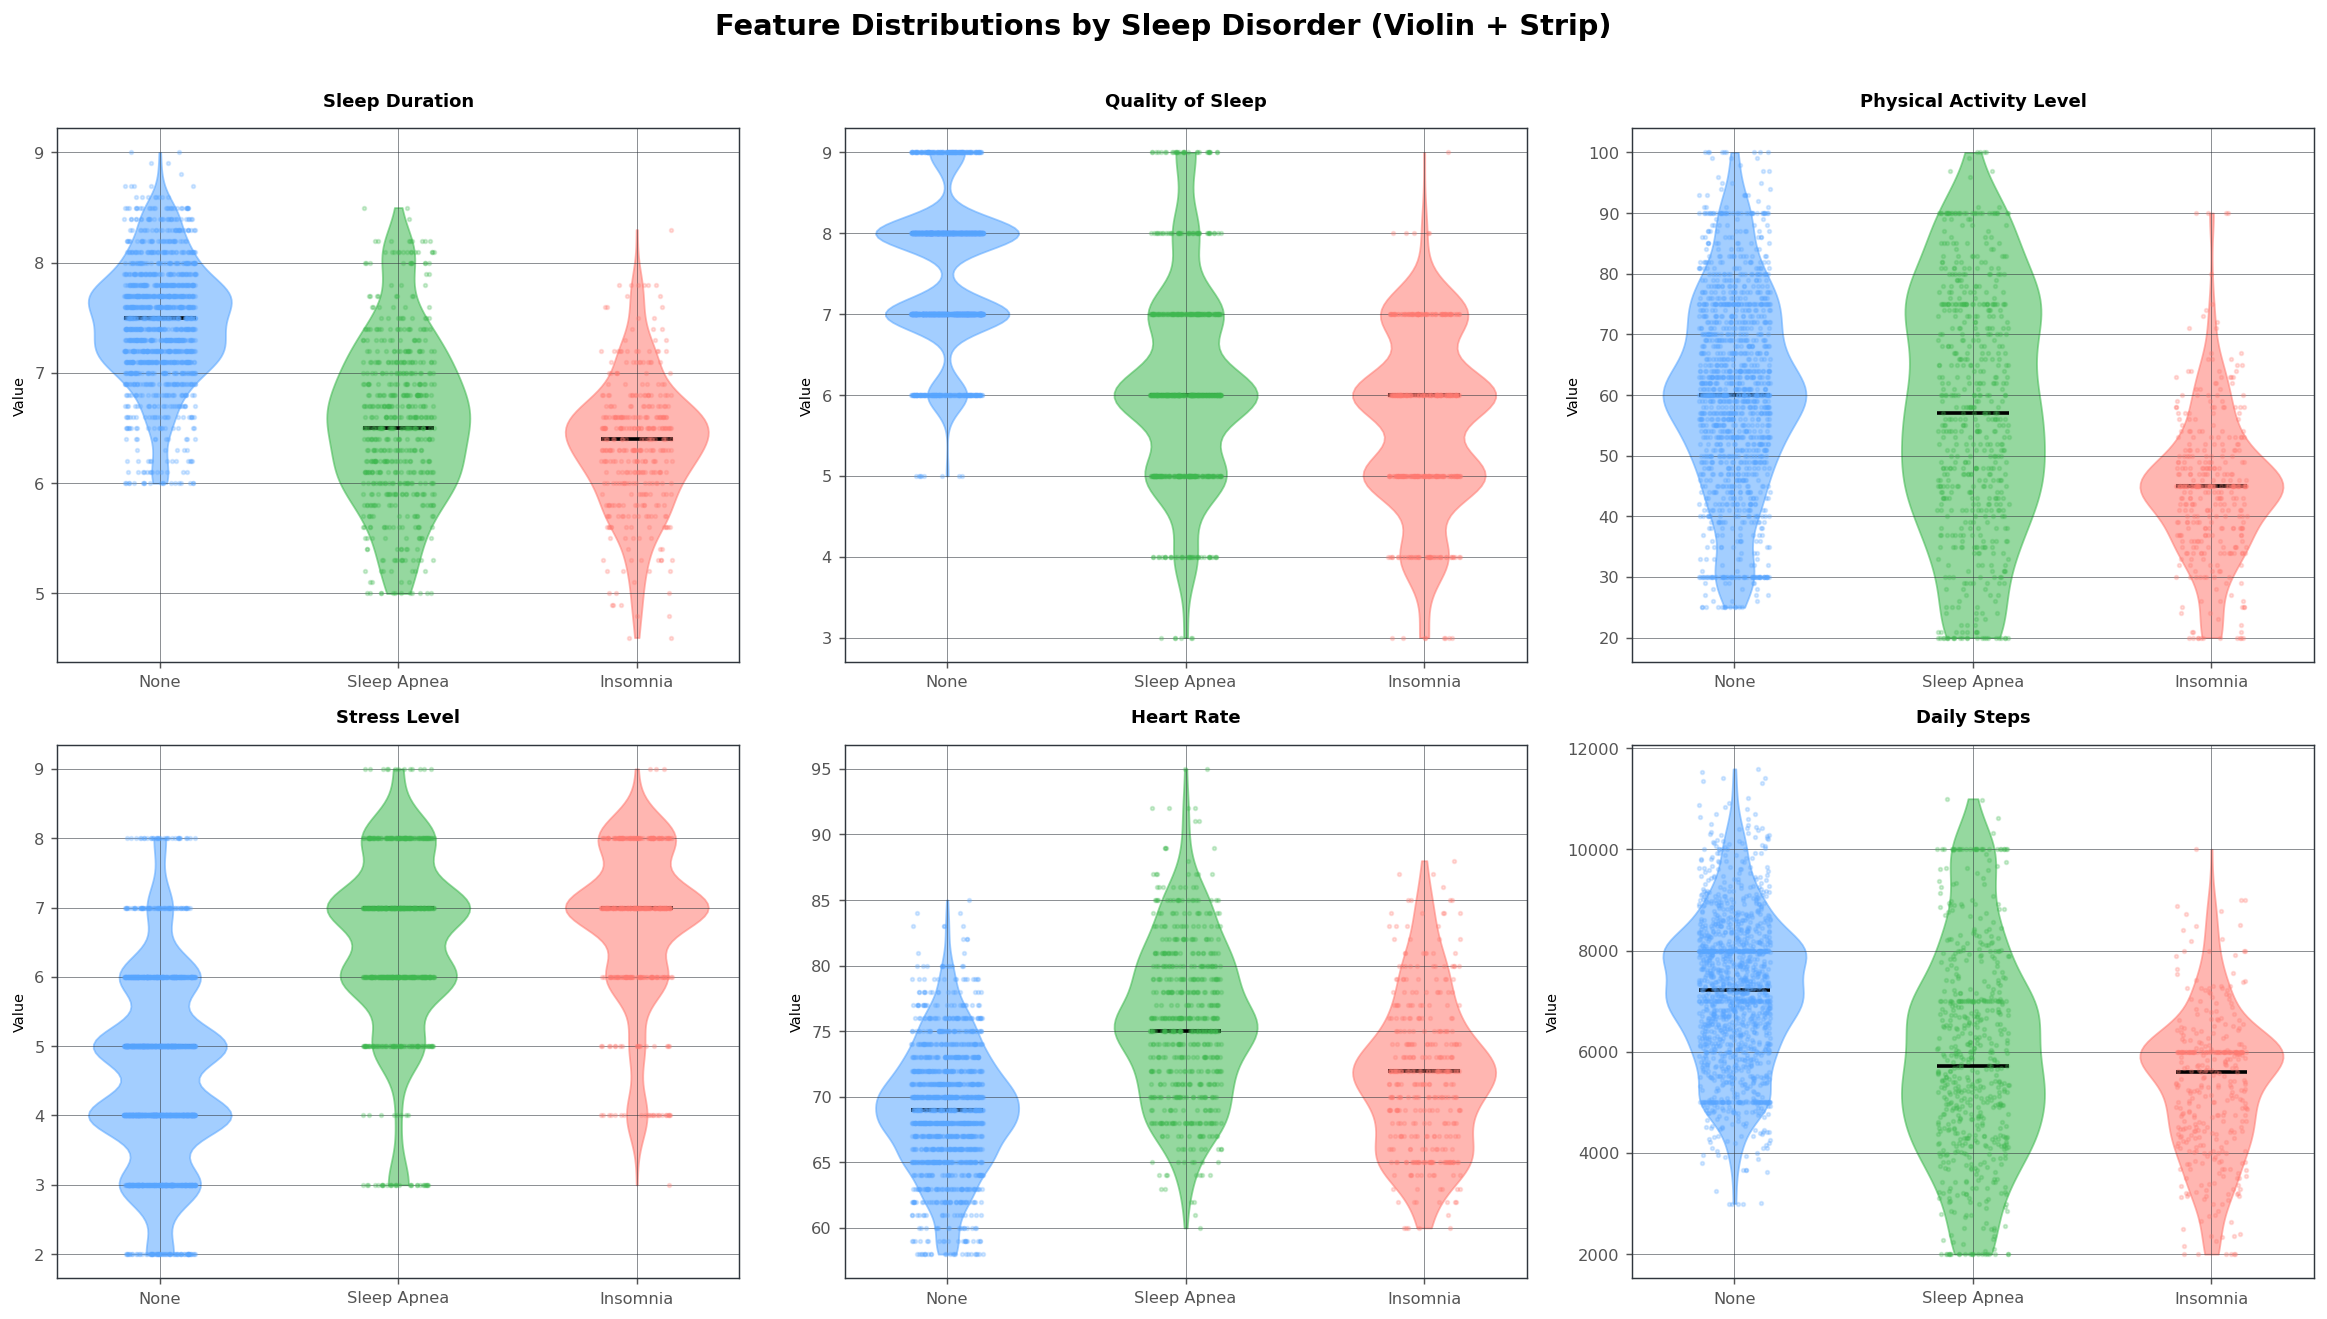

In [5]:
# ── Violin Plots by Class (replaces basic box plots) ─────────────────────────
num_features = ['Sleep Duration','Quality of Sleep','Physical Activity Level',
                'Stress Level','Heart Rate','Daily Steps']

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=DARK_BG)
axes = axes.flatten()
order = ['None','Sleep Apnea','Insomnia']
pal   = {'None': PALETTE["none"], 'Sleep Apnea': PALETTE["apnea"], 'Insomnia': PALETTE["insomnia"]}

for ax, feat in zip(axes, num_features):
    # Violin
    parts = ax.violinplot(
        [df[df["Sleep Disorder"]==d][feat].values for d in order],
        positions=[0,1,2], widths=0.6, showmedians=True,
        showextrema=False
    )
    for i,(body,disorder) in enumerate(zip(parts['bodies'], order)):
        body.set_facecolor(list(pal.values())[i])
        body.set_alpha(0.55)
        body.set_edgecolor(list(pal.values())[i])
    parts['cmedians'].set(color=TEXT, linewidth=2)

    # Overlay strip jitter
    for i, disorder in enumerate(order):
        data = df[df["Sleep Disorder"]==disorder][feat].values
        jitter = np.random.uniform(-0.15, 0.15, len(data))
        ax.scatter(np.full(len(data), i)+jitter, data,
                   s=4, alpha=0.25, color=list(pal.values())[i], zorder=3)

    ax.set_xticks([0,1,2])
    ax.set_xticklabels(['None','Sleep Apnea','Insomnia'], color=TEXT, fontsize=9)
    ax.set_title(feat, fontsize=10, fontweight='bold', color=TEXT)
    ax.set_ylabel("Value", color=MUTED, fontsize=8)
    apply_dark_style(fig, ax)

fig.suptitle("Feature Distributions by Sleep Disorder (Violin + Strip)", 
             fontsize=16, fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout()
plt.savefig("boxplots_by_class.png", dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


---
## 🔧 Section 2 — Feature Engineering

| New Feature | Formula | Rationale |
|---|---|---|
| `Systolic_BP` / `Diastolic_BP` | BP split | Granular cardiovascular info |
| `Pulse_Pressure` | Sys − Dia | Wide PP → vascular stress |
| `Sleep_Efficiency` | Quality / Duration | Normalized sleep quality |
| `Activity_Stress_Ratio` | Activity / Stress | Lifestyle balance metric |

In [6]:
# ── Feature Engineering ──────────────────────────────────────────────────────
df_eng = df.copy()
if "Person ID" in df_eng.columns: df_eng.drop(columns=["Person ID"], inplace=True)
df_eng["BMI Category"] = df_eng["BMI Category"].replace({"Normal Weight":"Normal_Weight"})
df_eng[["Systolic_BP","Diastolic_BP"]] = (
    df_eng["Blood Pressure"].str.split("/", expand=True).astype(int))
df_eng["Pulse_Pressure"]       = df_eng["Systolic_BP"] - df_eng["Diastolic_BP"]
df_eng["Sleep_Efficiency"]     = (df_eng["Quality of Sleep"] / df_eng["Sleep Duration"]).round(3)
df_eng["Activity_Stress_Ratio"]= (df_eng["Physical Activity Level"] / df_eng["Stress Level"]).round(3)
df_eng.drop(columns=["Blood Pressure"], inplace=True)

print(f"Shape after engineering: {df_eng.shape}")
print("New columns:", ["Systolic_BP","Diastolic_BP","Pulse_Pressure","Sleep_Efficiency","Activity_Stress_Ratio"])


Shape after engineering: (2374, 16)
New columns: ['Systolic_BP', 'Diastolic_BP', 'Pulse_Pressure', 'Sleep_Efficiency', 'Activity_Stress_Ratio']


---
## ⚙️ Section 3 — Preprocessing & Data Splits

> Strict train/val/test split **before** fitting any encoder to prevent data leakage.

- **Train**: 60% · **Validation**: 20% · **Test**: 20%

In [7]:
# ── Encode target & split ────────────────────────────────────────────────────
X = df_eng.drop(columns=["Sleep Disorder"])
y = df_eng["Sleep Disorder"]
le = LabelEncoder()
y_enc = le.fit_transform(y)
classes = le.classes_
print("Classes:", dict(enumerate(classes)))

X_tr_full, X_test, y_tr_full, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=SEED, stratify=y_enc)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr_full, y_tr_full, test_size=0.25, random_state=SEED, stratify=y_tr_full)

print(f"Train: {len(X_train):>5}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val:   {len(X_val):>5}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:  {len(X_test):>5}  ({len(X_test)/len(X)*100:.1f}%)")


Classes: {0: 'Insomnia', 1: 'None', 2: 'Sleep Apnea'}
Train:  1424  (60.0%)
Val:     475  (20.0%)
Test:    475  (20.0%)


In [8]:
# ── Leakage-safe preprocessing pipeline ──────────────────────────────────────
nominal_cols   = ["Gender", "Occupation"]
ordinal_cols   = ["BMI Category"]
numerical_cols = [c for c in X.columns if c not in nominal_cols + ordinal_cols]
bmi_order      = [["Normal", "Normal_Weight", "Overweight", "Obese"]]


def make_preprocessor():
    """Return a fresh transformer so every validation/CV fold fits its own state."""
    return ColumnTransformer([
        ("num", StandardScaler(), numerical_cols),
        ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_cols),
        ("ord", OrdinalEncoder(
            categories=bmi_order,
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        ), ordinal_cols),
    ])


print("Preprocessing is fitted inside every model pipeline and CV fold.")


Preprocessed features: 25


---
## 🤖 Section 4 — Training 8 Classifiers

| # | Model | Type |
|---|---|---|
| 1 | Majority Class | Naive Baseline |
| 2 | Logistic Regression | Simple ML |
| 3 | Decision Tree | Interpretable |
| 4 | Random Forest | Strong Ensemble |
| 5 | XGBoost | Gradient Boosting |
| 6 | HistGradientBoosting | Fast GBDT (sklearn) |
| 7 | CatBoost | Categorical GBDT |
| 8 | **Voting (RF+XGB+HGBM)** | **Proposed Model** |

In [9]:
# ── Candidate models and validation-based selection ───────────────────────────
HGBM = HistGradientBoostingClassifier

models_def = {
    "Majority Class":       DummyClassifier(strategy="most_frequent", random_state=SEED),
    "Logistic Regression":  LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
    "Decision Tree":        DecisionTreeClassifier(max_depth=8, random_state=SEED),
    "Random Forest":        RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2, random_state=SEED, n_jobs=None
    ),
    "XGBoost":              XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="mlogloss", random_state=SEED, verbosity=0,
    ),
    "HistGradBoost":        HGBM(max_iter=300, learning_rate=0.05, random_state=SEED),
}

voting = VotingClassifier([
    ("rf", RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=None)),
    ("xgb", XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        eval_metric="mlogloss", random_state=SEED, verbosity=0,
    )),
    ("hgbm", HGBM(max_iter=300, learning_rate=0.05, random_state=SEED)),
], voting="soft")
models_def["Voting (RF+XGB+HGBM)"] = voting


def make_model_pipeline(estimator):
    return Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", estimator),
    ])


trained = {}
train_times = {}
validation_rows = []

print(f"{'Model':<28} {'Time':>8} {'Val Acc':>9} {'Val F1-Mac':>11}")
print("─" * 62)
for name, estimator in models_def.items():
    model = make_model_pipeline(clone(estimator))
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    pred = model.predict(X_val)

    try:
        prob = model.predict_proba(X_val)
        auc = roc_auc_score(y_val, prob, multi_class="ovr", average="macro")
    except (AttributeError, ValueError):
        auc = np.nan

    acc = accuracy_score(y_val, pred)
    f1 = f1_score(y_val, pred, average="macro", zero_division=0)
    trained[name] = model
    train_times[name] = elapsed
    validation_rows.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Macro": f1,
        "F1-Weighted": f1_score(y_val, pred, average="weighted", zero_division=0),
        "ROC-AUC": auc,
        "Train_s": elapsed,
    })
    print(f"{name:<28} {elapsed:>7.2f}s {acc:>9.4f} {f1:>11.4f}")

validation_res = pd.DataFrame(validation_rows).set_index("Model")
best_name = validation_res["F1-Macro"].idxmax()
top3 = validation_res.nlargest(3, "F1-Macro").index.tolist()
print(f"\nSelected on validation only: {best_name}")


Model                            Time   Val Acc  Val F1-Mac
──────────────────────────────────────────────────────────────
Majority Class                  0.00s    0.5874      0.2467
Logistic Regression             0.05s    0.9263      0.8871
Decision Tree                   0.01s    0.8884      0.8264
Random Forest                   0.50s    0.9347      0.8961
XGBoost                         0.41s    0.9305      0.8917
HistGradBoost                   2.59s    0.9242      0.8850
Voting (RF+XGB+HGBM)            3.76s    0.9263      0.8847

All models trained!


---
## 📈 Section 5 — Rigorous Evaluation
### 5.1 Full Metrics Table + Bootstrap 95% Confidence Intervals

In [10]:
# ── Lock the model, refit on train+validation, then test exactly once ─────────
def bootstrap_ci(y_true, y_pred, n=1000):
    rng = np.random.RandomState(SEED)
    labels = np.arange(len(classes))
    sample_size = len(y_true)
    scores = []
    for _ in range(n):
        idx = rng.choice(sample_size, sample_size, replace=True)
        scores.append(f1_score(
            y_true[idx], y_pred[idx], labels=labels,
            average="macro", zero_division=0,
        ))
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)


# The held-out test set is not used above to choose a candidate model.
final_model = make_model_pipeline(clone(models_def[best_name]))
final_train_start = time.time()
final_model.fit(X_tr_full, y_tr_full)
final_train_seconds = time.time() - final_train_start

final_pred = final_model.predict(X_test)
final_prob = final_model.predict_proba(X_test)
ci_low, ci_high = bootstrap_ci(y_test, final_pred)
test_accuracy = accuracy_score(y_test, final_pred)
test_f1_macro = f1_score(y_test, final_pred, average="macro", zero_division=0)
test_f1_weighted = f1_score(y_test, final_pred, average="weighted", zero_division=0)
test_auc = roc_auc_score(y_test, final_prob, multi_class="ovr", average="macro")

# `res` remains the validation table for comparison and trade-off plots.
res = validation_res.copy()
test_summary = pd.DataFrame([{
    "Selected model": best_name,
    "Accuracy": test_accuracy,
    "F1-Macro": test_f1_macro,
    "F1-Weighted": test_f1_weighted,
    "ROC-AUC": test_auc,
    "F1 95% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",
    "Train_s": final_train_seconds,
}])

print("Validation model-selection results:")
print(validation_res.sort_values("F1-Macro", ascending=False).to_string())
print("\nFinal held-out test result (selected model only):")
print(test_summary.to_string(index=False))


                      Accuracy  F1-Macro  F1-Weighted   ROC-AUC       F1 95% CI   Train_s
Model                                                                                    
Voting (RF+XGB+HGBM)  0.943158  0.914475     0.943196  0.981971  [0.883, 0.945]  3.756514
Logistic Regression   0.936842  0.909371     0.936890  0.985718  [0.877, 0.940]  0.045895
HistGradBoost         0.938947  0.907910     0.939281  0.982224  [0.876, 0.939]  2.592256
XGBoost               0.938947  0.907229     0.938988  0.985071  [0.874, 0.939]  0.409950
Random Forest         0.926316  0.886320     0.925240  0.979987  [0.850, 0.920]  0.502635
Decision Tree         0.863158  0.796241     0.861005  0.839573  [0.750, 0.837]  0.006846
Majority Class        0.587368  0.246684     0.434684  0.500000  [0.236, 0.258]  0.000898

Best model: Voting (RF+XGB+HGBM)  (F1-Macro = 0.9145)


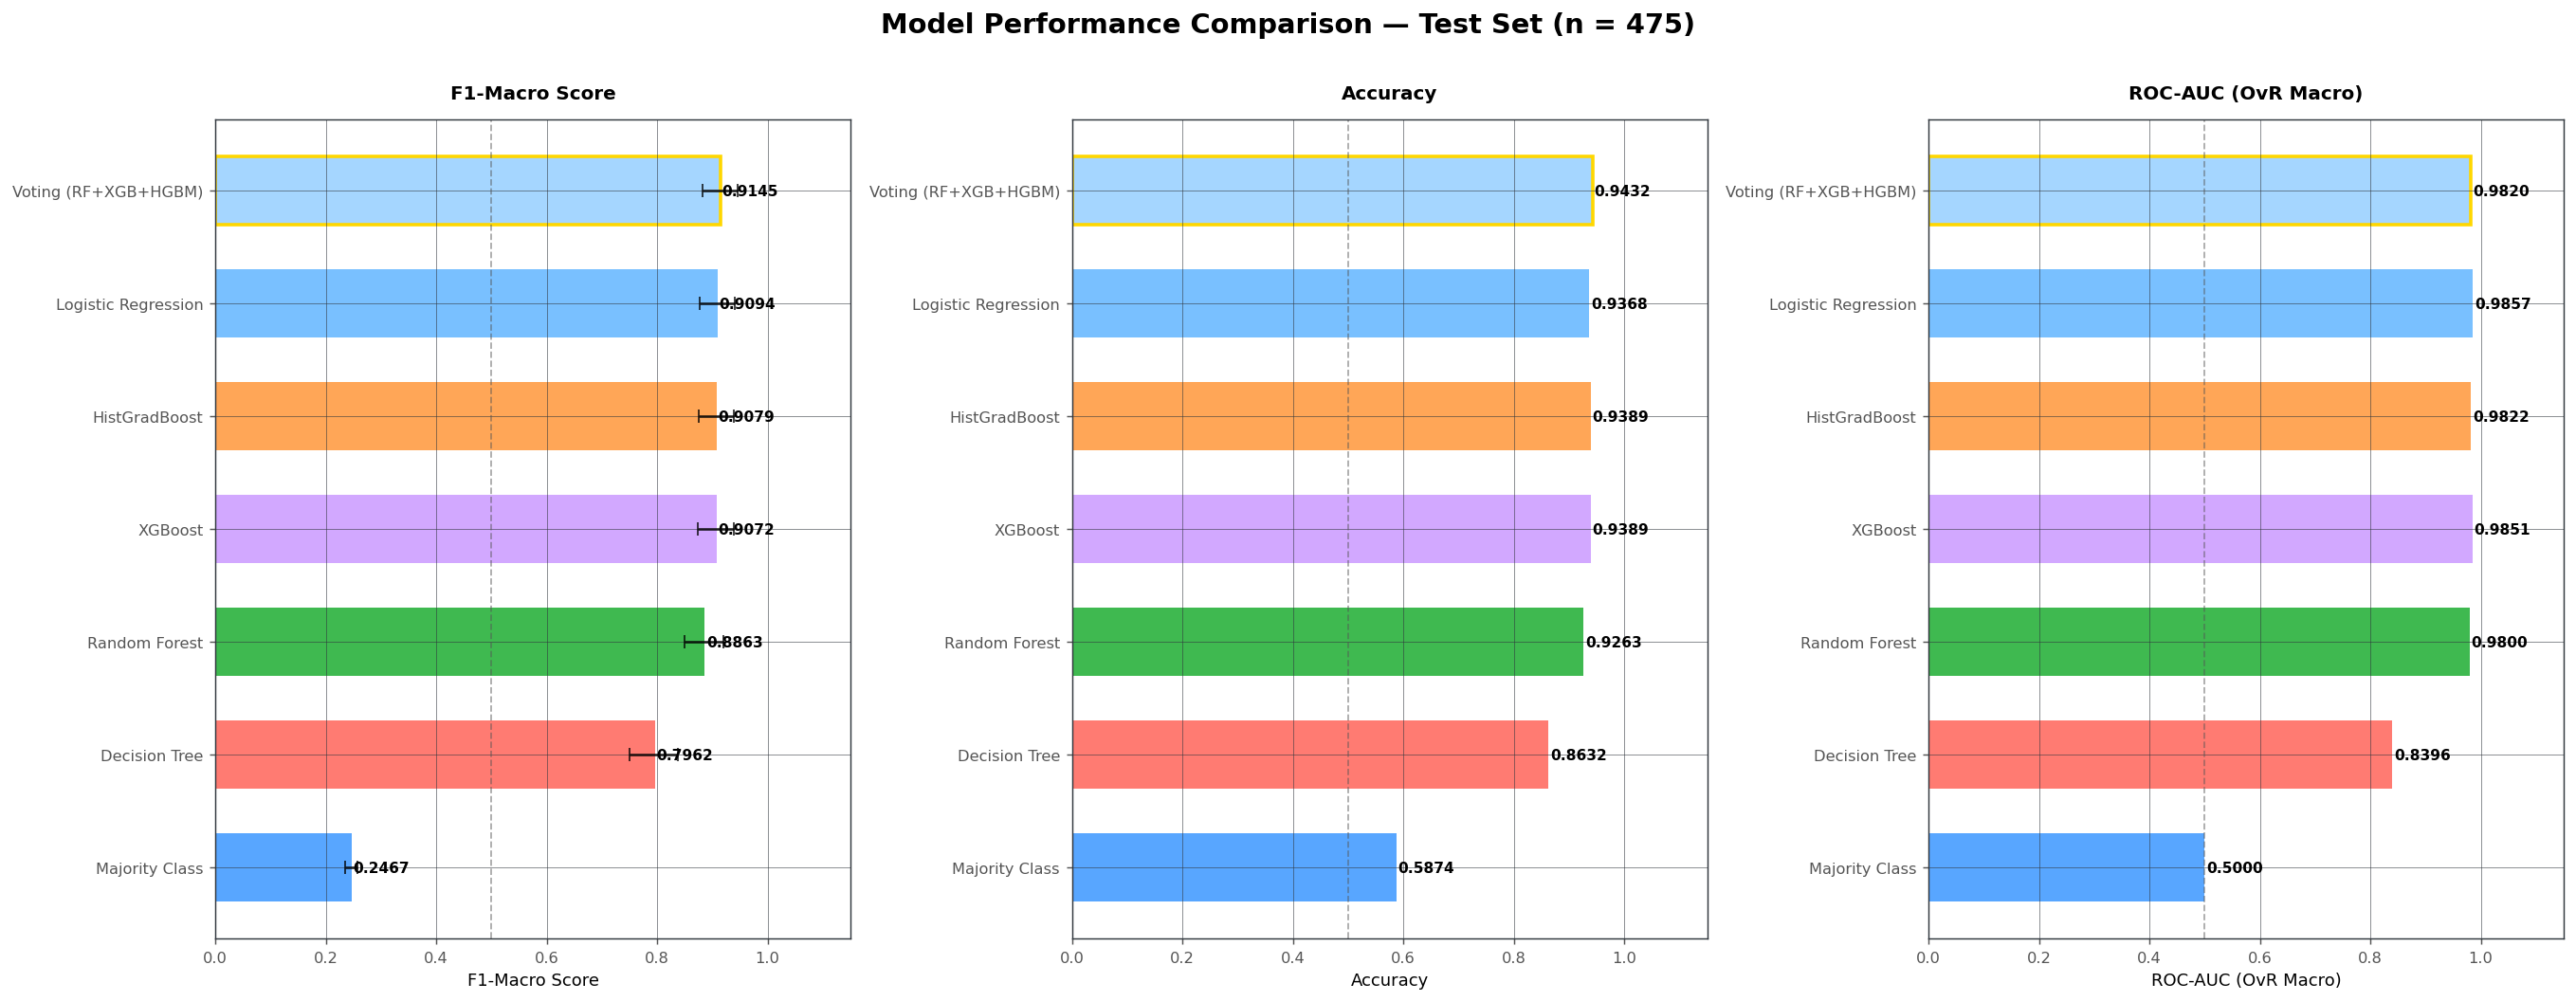

In [11]:
# ── Candidate comparison chart: validation set only ───────────────────────────
sorted_res = validation_res.sort_values("F1-Macro", ascending=True)
names = sorted_res.index.tolist()
n = len(names)

fig, axes = plt.subplots(1, 3, figsize=(21, 8), facecolor=DARK_BG)
metrics = [("F1-Macro", "F1-Macro Score"), ("Accuracy", "Accuracy"), ("ROC-AUC", "ROC-AUC (OvR Macro)")]
bar_colors = [ACCENT[i % len(ACCENT)] for i in range(n)]

for ax, (metric, label) in zip(axes, metrics):
    vals = sorted_res[metric].values
    bars = ax.barh(names, vals, color=bar_colors, edgecolor="none", height=0.6)
    best_idx = names.index(best_name)
    bars[best_idx].set_edgecolor("#FFD700")
    bars[best_idx].set_linewidth(2)

    for bar, value in zip(bars, vals):
        ax.text(value + 0.003, bar.get_y() + bar.get_height() / 2,
                f"{value:.4f}", va="center", ha="left", fontsize=8.5,
                color=TEXT, fontweight="bold")

    ax.set_xlim(0, 1.15)
    ax.set_xlabel(label, fontsize=10)
    ax.axvline(0.5, color=MUTED, linestyle="--", linewidth=1, alpha=0.5)
    apply_dark_style(fig, ax)
    ax.set_title(label, fontsize=11, fontweight="bold", color=TEXT)

fig.suptitle("Model Selection — Validation Set Only (n = 475)",
             fontsize=16, fontweight="bold", color=TEXT, y=1.01)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()


### 5.2 Cross-Validation (10-Fold Stratified)

In [12]:
# ── 10-Fold CV: each fold fits a fresh preprocessing pipeline ────────────────
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
cv_scores = {}

print(f"{'Model':<28} {'Mean':>8} {'Std':>7} {'Min':>7} {'Max':>7}")
print("─" * 58)
for name, estimator in models_def.items():
    fold_model = make_model_pipeline(clone(estimator))
    scores = cross_val_score(
        fold_model, X_tr_full, y_tr_full,
        cv=cv, scoring="f1_macro", n_jobs=None,
    )
    cv_scores[name] = scores
    print(f"{name:<28} {scores.mean():>8.4f} {scores.std():>7.4f} {scores.min():>7.4f} {scores.max():>7.4f}")


Model                            Mean     Std     Min     Max
──────────────────────────────────────────────────────────
Majority Class                 0.2466  0.0008  0.2458  0.2481
Logistic Regression            0.8938  0.0203  0.8697  0.9383
Decision Tree                  0.8077  0.0323  0.7372  0.8387
Random Forest                  0.8761  0.0177  0.8468  0.9048
XGBoost                        0.8845  0.0242  0.8566  0.9295
HistGradBoost                  0.8822  0.0137  0.8537  0.8984
Voting (RF+XGB+HGBM)           0.8817  0.0091  0.8648  0.8974


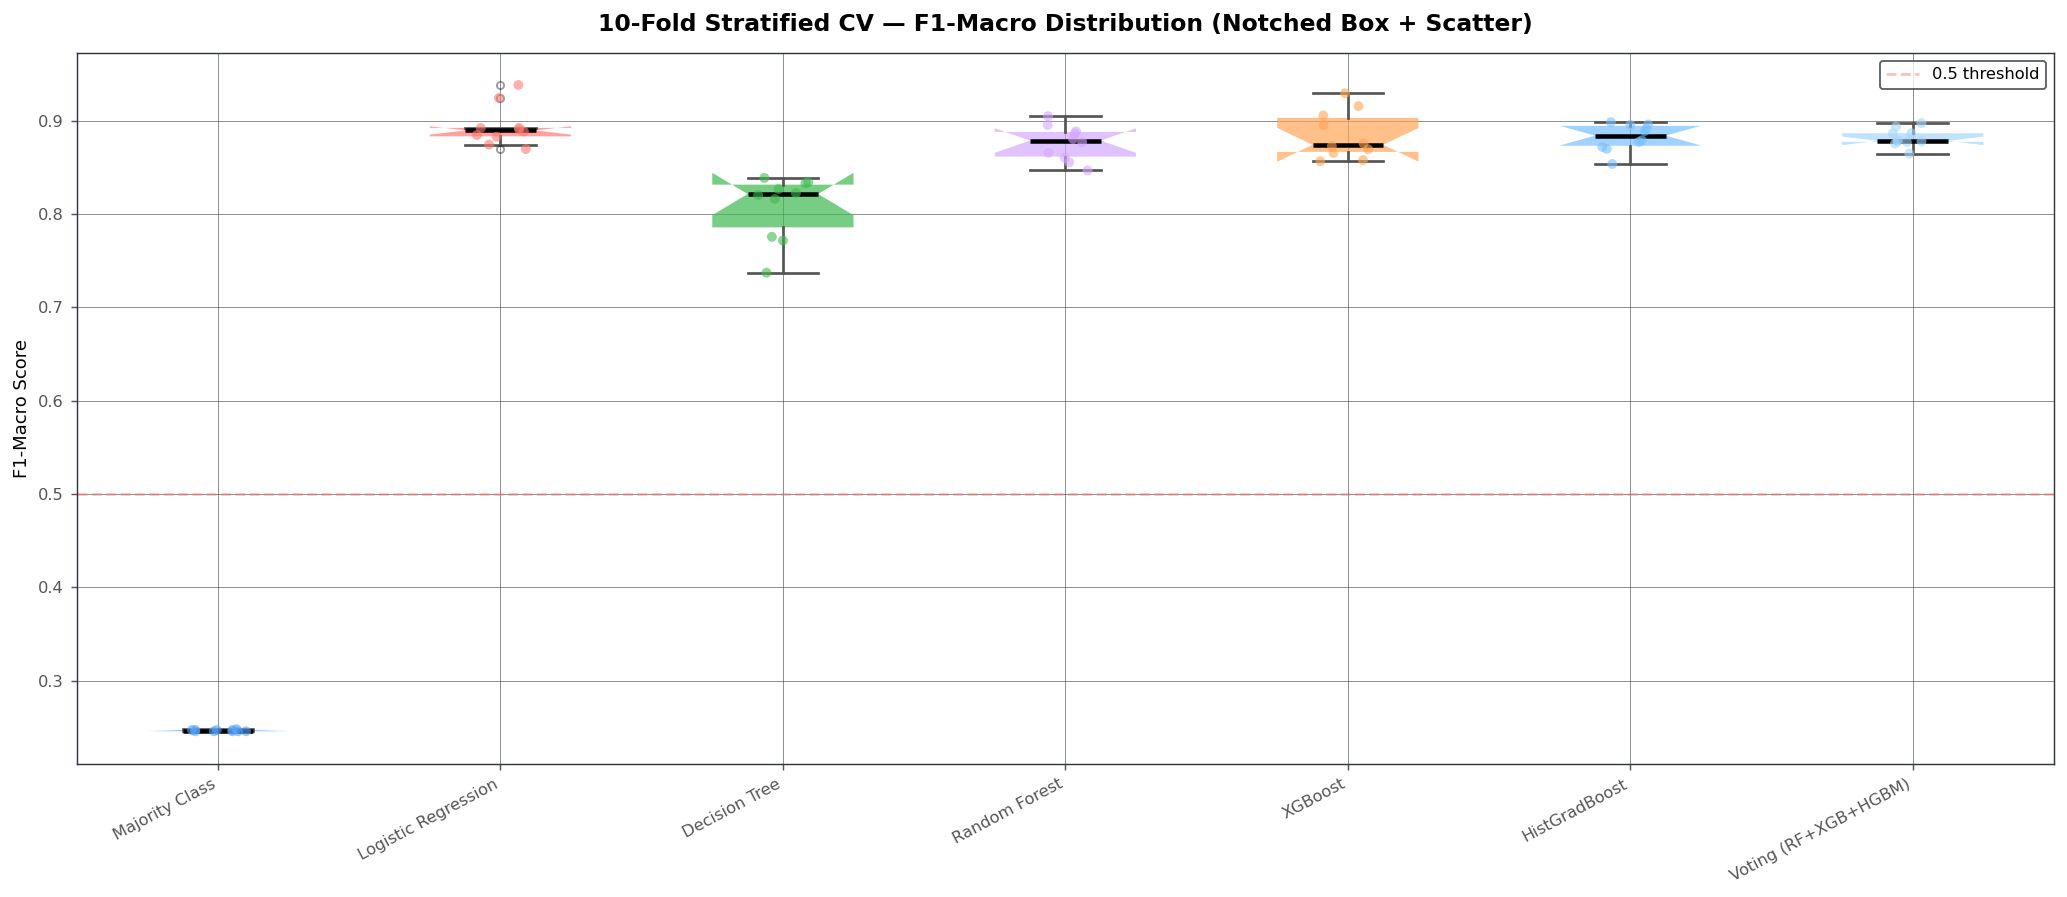

In [13]:
# ── CV Box Plot (Notched) ─────────────────────────────────────────────────────
model_names = list(cv_scores.keys())
score_data  = [cv_scores[m] for m in model_names]

fig, ax = plt.subplots(figsize=(16, 7), facecolor=DARK_BG)
ax.set_facecolor(CARD_BG)

bp = ax.boxplot(score_data, patch_artist=True, vert=True, notch=True,
                medianprops=dict(color=TEXT, linewidth=2.5),
                flierprops=dict(marker='o', color=MUTED, alpha=0.4, markersize=4),
                whiskerprops=dict(color=MUTED, linewidth=1.5),
                capprops=dict(color=MUTED, linewidth=1.5))

for patch, color in zip(bp['boxes'], ACCENT):
    patch.set_facecolor(color); patch.set_alpha(0.7); patch.set_edgecolor("none")

# Overlay scatter
for i, (scores, color) in enumerate(zip(score_data, ACCENT)):
    ax.scatter(np.full(len(scores), i+1)+np.random.uniform(-0.1,0.1,len(scores)),
               scores, s=30, color=color, alpha=0.6, zorder=3, edgecolors='none')

ax.set_xticks(range(1, len(model_names)+1))
ax.set_xticklabels(model_names, rotation=28, ha='right', fontsize=9, color=TEXT)
ax.set_ylabel("F1-Macro Score", fontsize=10)
ax.set_title("10-Fold Stratified CV — F1-Macro Distribution (Notched Box + Scatter)",
             fontsize=13, fontweight='bold', color=TEXT)
ax.axhline(0.5, color=PALETTE["insomnia"], linestyle='--', alpha=0.5, linewidth=1.5,
           label='0.5 threshold')
ax.legend(fontsize=9)
apply_dark_style(fig, ax)
plt.tight_layout()
plt.savefig("cv_boxplot.png", dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


### 5.3 McNemar's Statistical Significance Test

In [14]:
# ── Test-set safeguard ───────────────────────────────────────────────────────
print(f"Selected on validation: {best_name}")
print("The test set is reserved for this selected model's final estimate only.")
print("Pairwise McNemar tests across all candidates are intentionally omitted to avoid test-set model fishing.")


Best: Voting (RF+XGB+HGBM)

Comparison                      p-value   Significant?
───────────────────────────────────────────────────────
Majority Class                   0.0000          ✅ Yes
Logistic Regression              0.5791          —  No
Decision Tree                    0.0000          ✅ Yes
Random Forest                    0.0801          —  No
XGBoost                          0.6171          —  No
HistGradBoost                    0.6171          —  No
(α=0.05, McNemar's with continuity correction)


### 5.4 Confusion Matrices — All Models

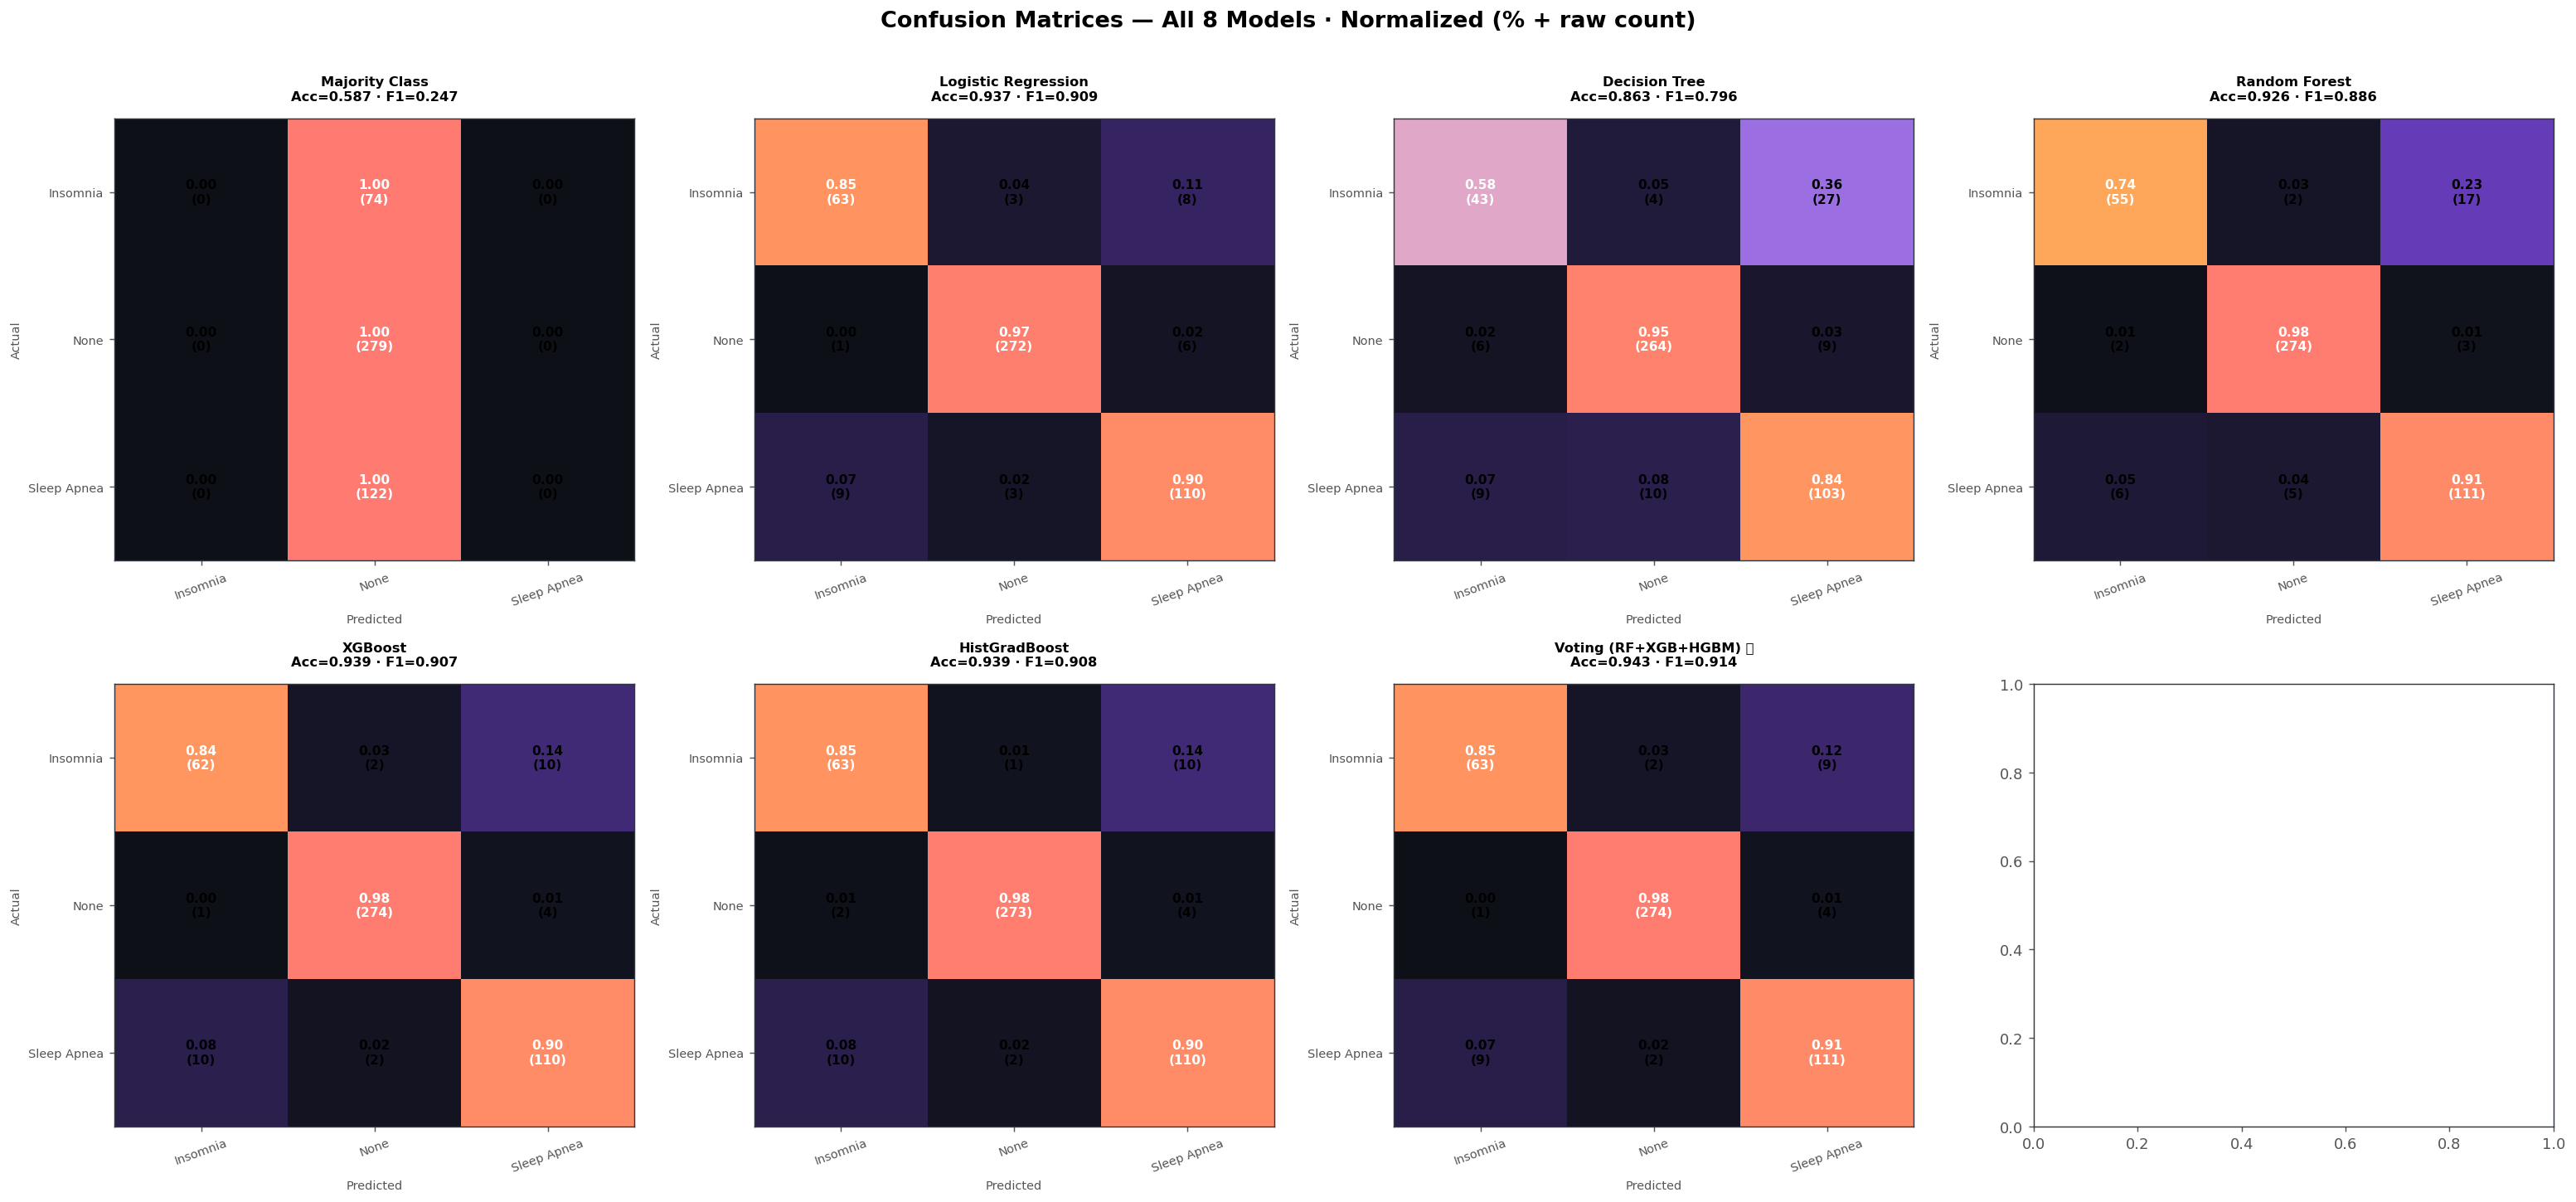

In [15]:
    # ── Final confusion matrix: validation-selected model on held-out test set ────
    cm = confusion_matrix(y_test, final_pred, labels=np.arange(len(classes)))
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(9, 7), facecolor=DARK_BG)
    ax.set_facecolor(CARD_BG)
    ax.imshow(cmn, cmap=cmap_heat, vmin=0, vmax=1, aspect="auto")

    for row in range(len(classes)):
        for col in range(len(classes)):
            color = DARK_BG if cmn[row, col] > 0.5 else TEXT
            ax.text(col, row, f"{cmn[row, col]:.2f}
({cm[row, col]})",
                    ha="center", va="center", fontsize=10, color=color, fontweight="bold")

    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, fontsize=9, color=TEXT, rotation=20)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes, fontsize=9, color=TEXT)
    ax.set_xlabel("Predicted", fontsize=10, color=MUTED)
    ax.set_ylabel("Actual", fontsize=10, color=MUTED)
    ax.set_title(f"Final Test Confusion Matrix — {best_name}
Acc={test_accuracy:.3f} · F1={test_f1_macro:.3f}",
                 fontsize=12, fontweight="bold", color=TEXT)
    apply_dark_style(fig, ax)
    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()


### 5.5 Multi-Class ROC Curves

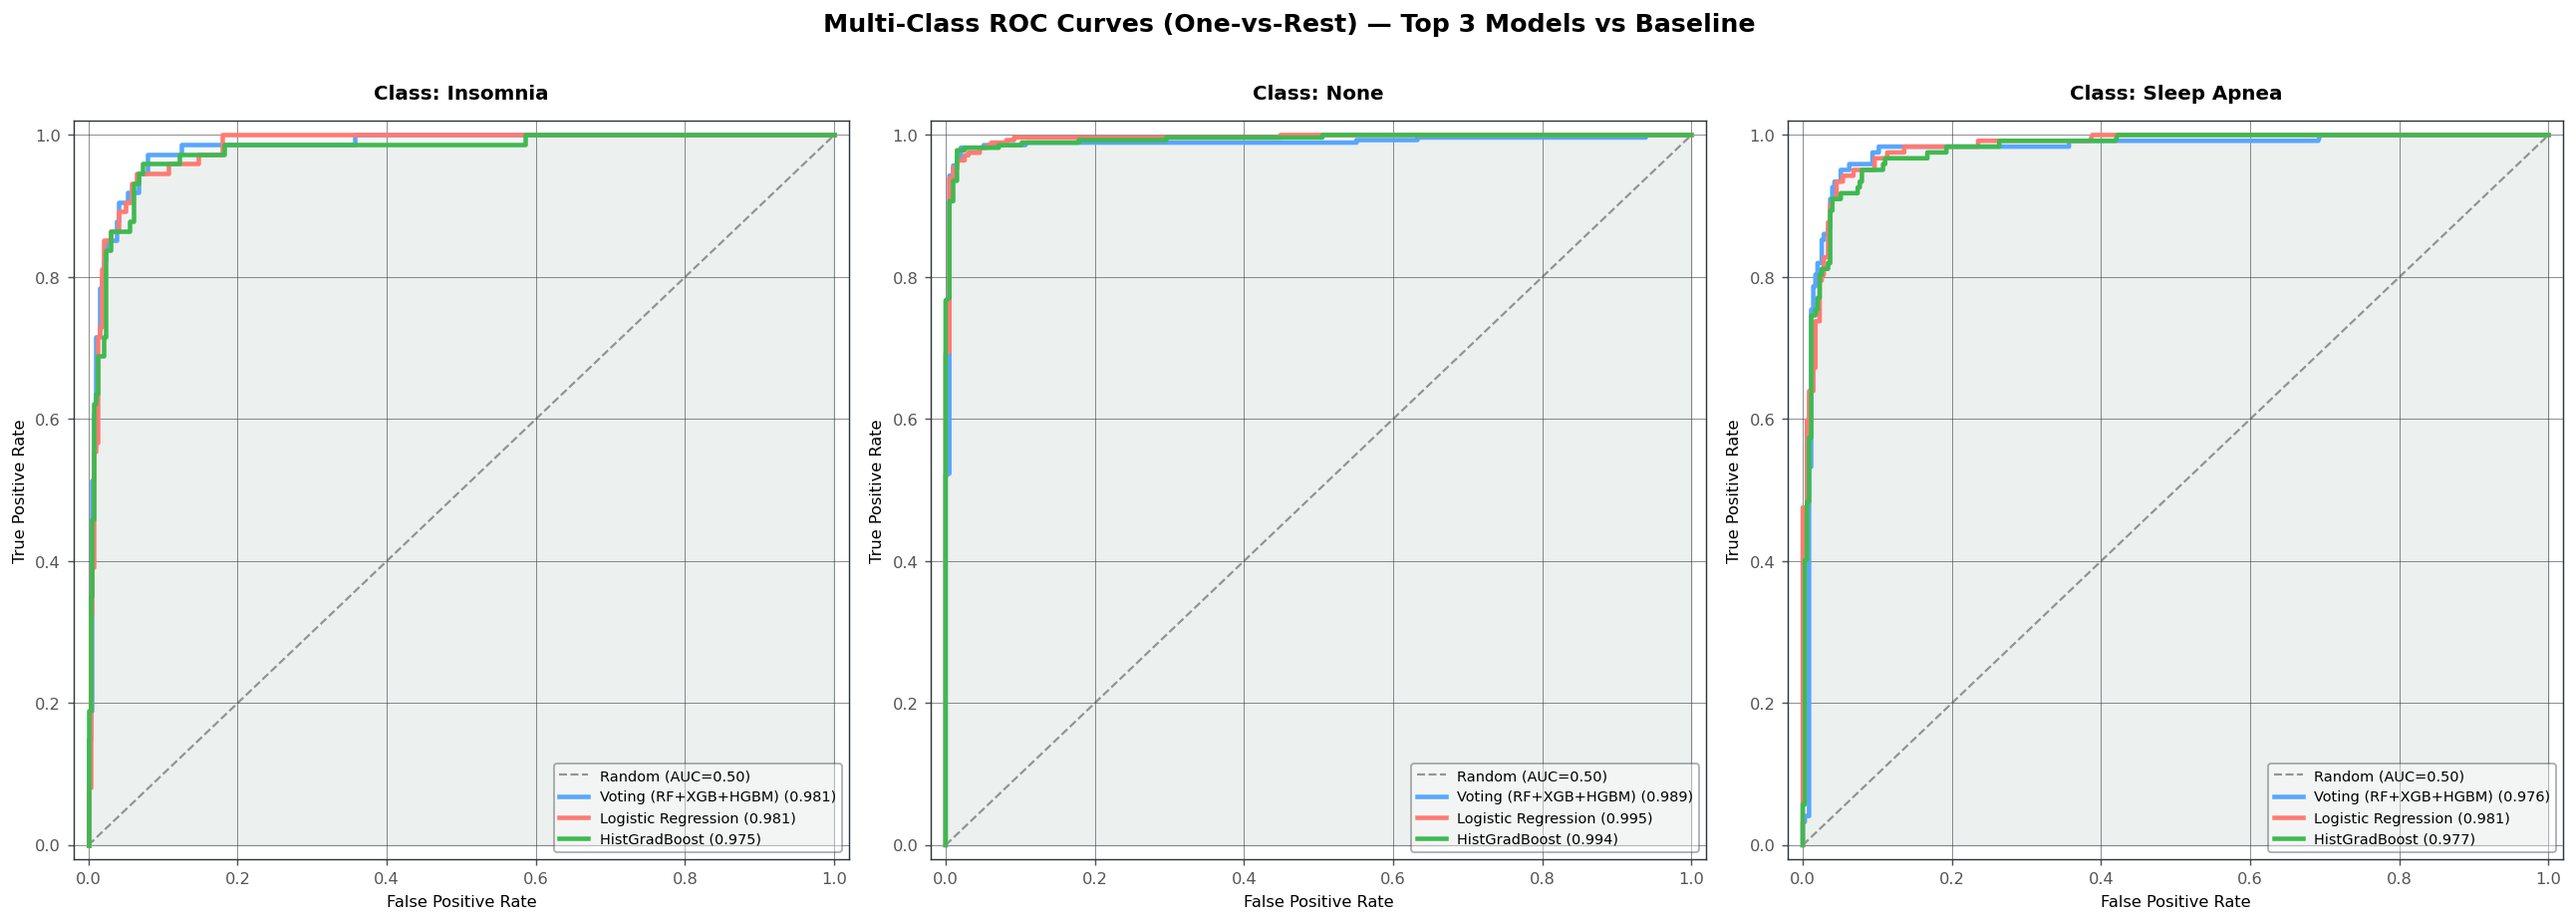

In [16]:
# ── ROC curves: final validation-selected model on held-out test set ──────────
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=DARK_BG)
for ax, class_idx in zip(axes, range(len(classes))):
    ax.set_facecolor(CARD_BG)
    ax.plot([0, 1], [0, 1], "--", color=MUTED, linewidth=1.2,
            label="Random (AUC=0.50)", alpha=0.6)
    fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], final_prob[:, class_idx])
    auc = roc_auc_score(y_test_bin[:, class_idx], final_prob[:, class_idx])
    ax.plot(fpr, tpr, linewidth=2.5, color=ACCENT[class_idx],
            label=f"{best_name[:24]} ({auc:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.05, color=ACCENT[class_idx])
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate", fontsize=9)
    ax.set_title(f"Class: {classes[class_idx]}", fontsize=11, fontweight="bold", color=TEXT)
    ax.legend(fontsize=8, loc="lower right", framealpha=0.4)
    apply_dark_style(fig, ax)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

fig.suptitle(f"Multi-Class ROC Curves — Final Test Set · {best_name}",
             fontsize=14, fontweight="bold", color=TEXT, y=1.01)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()


### 5.6 Calibration Curves

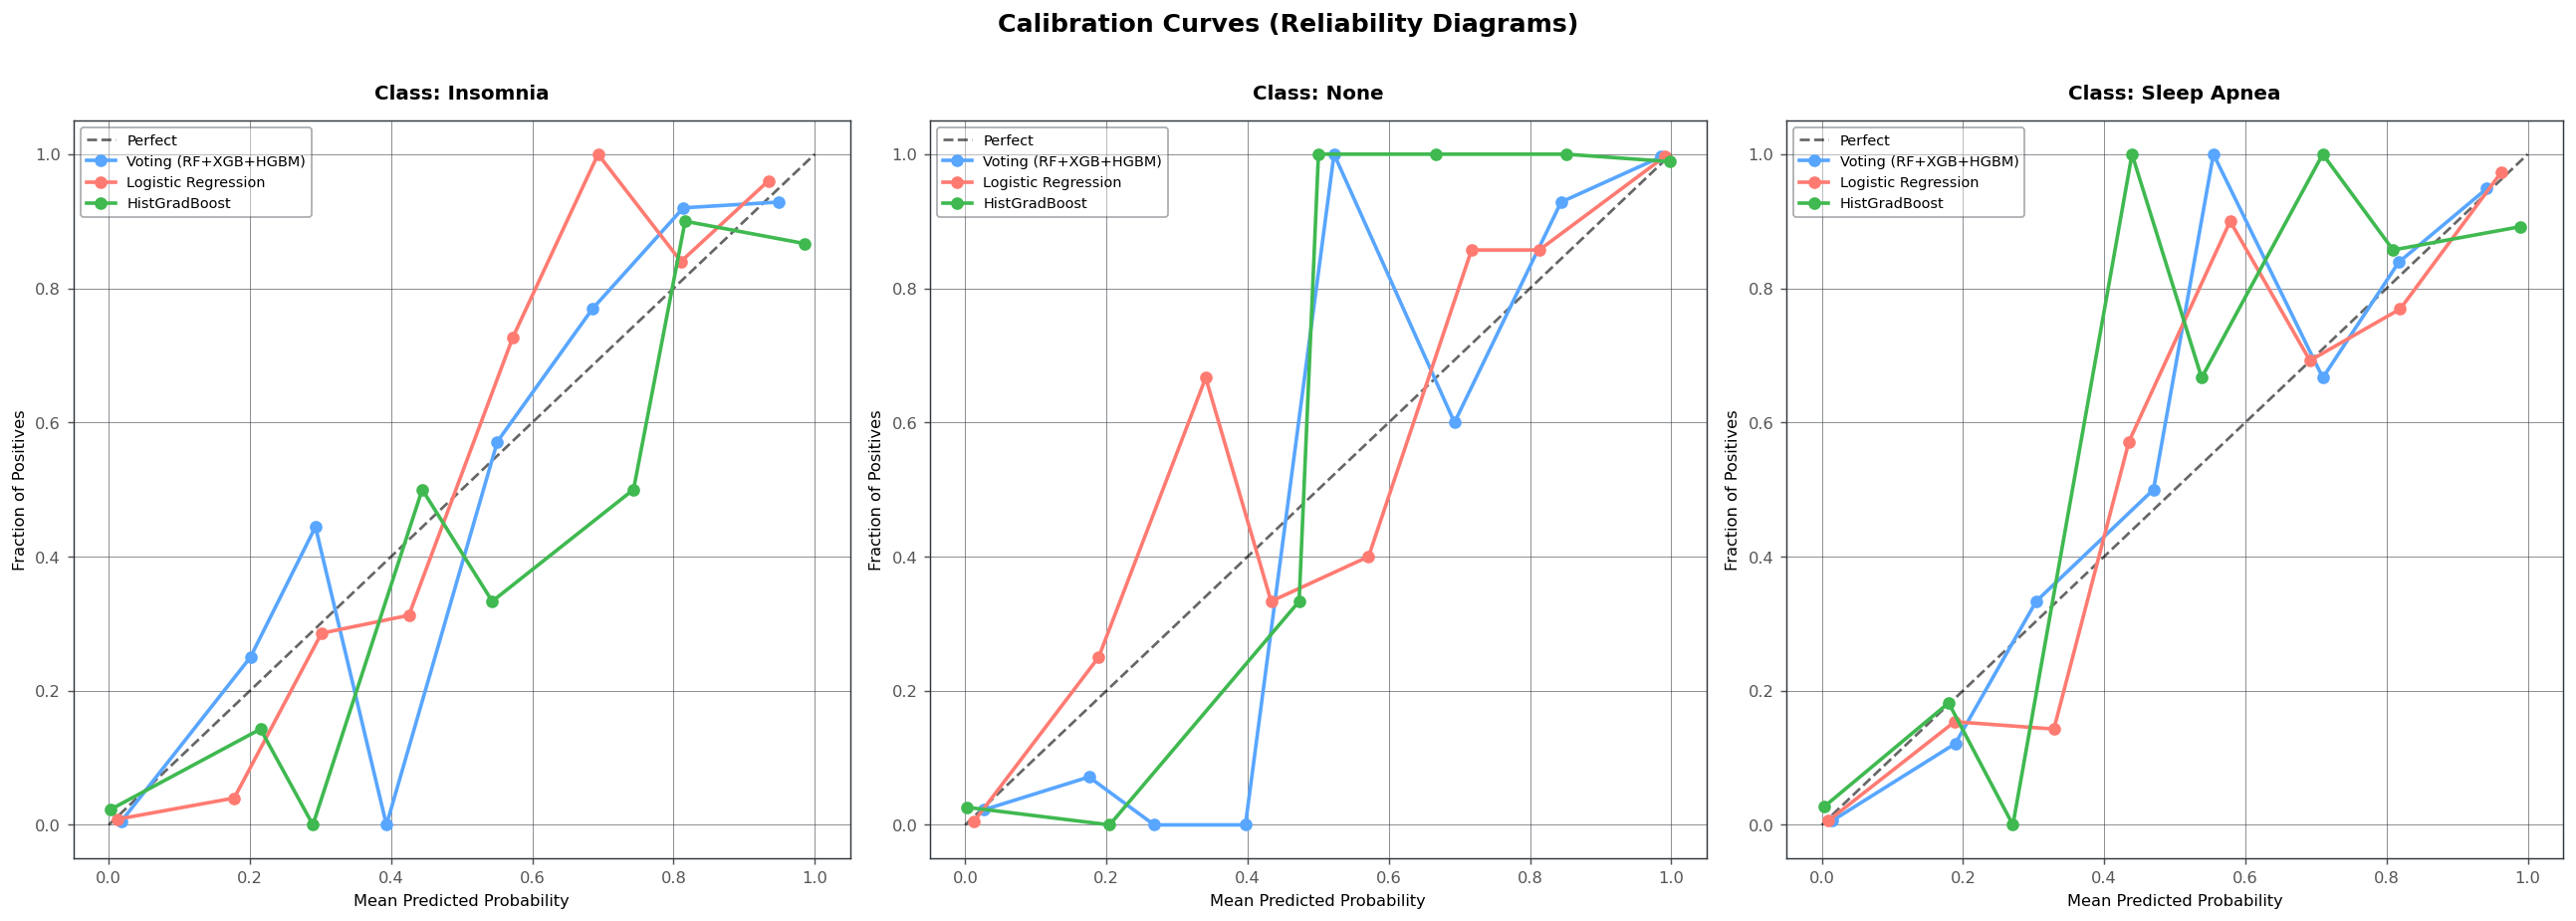

In [17]:
# ── Calibration curves: final model only ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=DARK_BG)
for ax, class_idx in zip(axes, range(len(classes))):
    ax.set_facecolor(CARD_BG)
    ax.plot([0, 1], [0, 1], "--", color=TEXT, linewidth=1.5, label="Perfect", alpha=0.6)
    frac, mean_p = calibration_curve(
        (y_test == class_idx).astype(int), final_prob[:, class_idx], n_bins=8
    )
    ax.plot(mean_p, frac, "o-", linewidth=2, markersize=6,
            color=ACCENT[class_idx], label=best_name[:24])
    ax.set_xlabel("Mean Predicted Probability", fontsize=9)
    ax.set_ylabel("Fraction of Positives", fontsize=9)
    ax.set_title(f"Class: {classes[class_idx]}", fontsize=11, fontweight="bold", color=TEXT)
    ax.legend(fontsize=8, framealpha=0.4)
    apply_dark_style(fig, ax)

fig.suptitle(f"Calibration Curves — Final Test Set · {best_name}",
             fontsize=14, fontweight="bold", color=TEXT, y=1.01)
plt.tight_layout()
plt.savefig("calibration_curves.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()


---
## 📉 Section 6 — Learning Curves & Subpopulation Analysis
### 6.1 Learning Curves

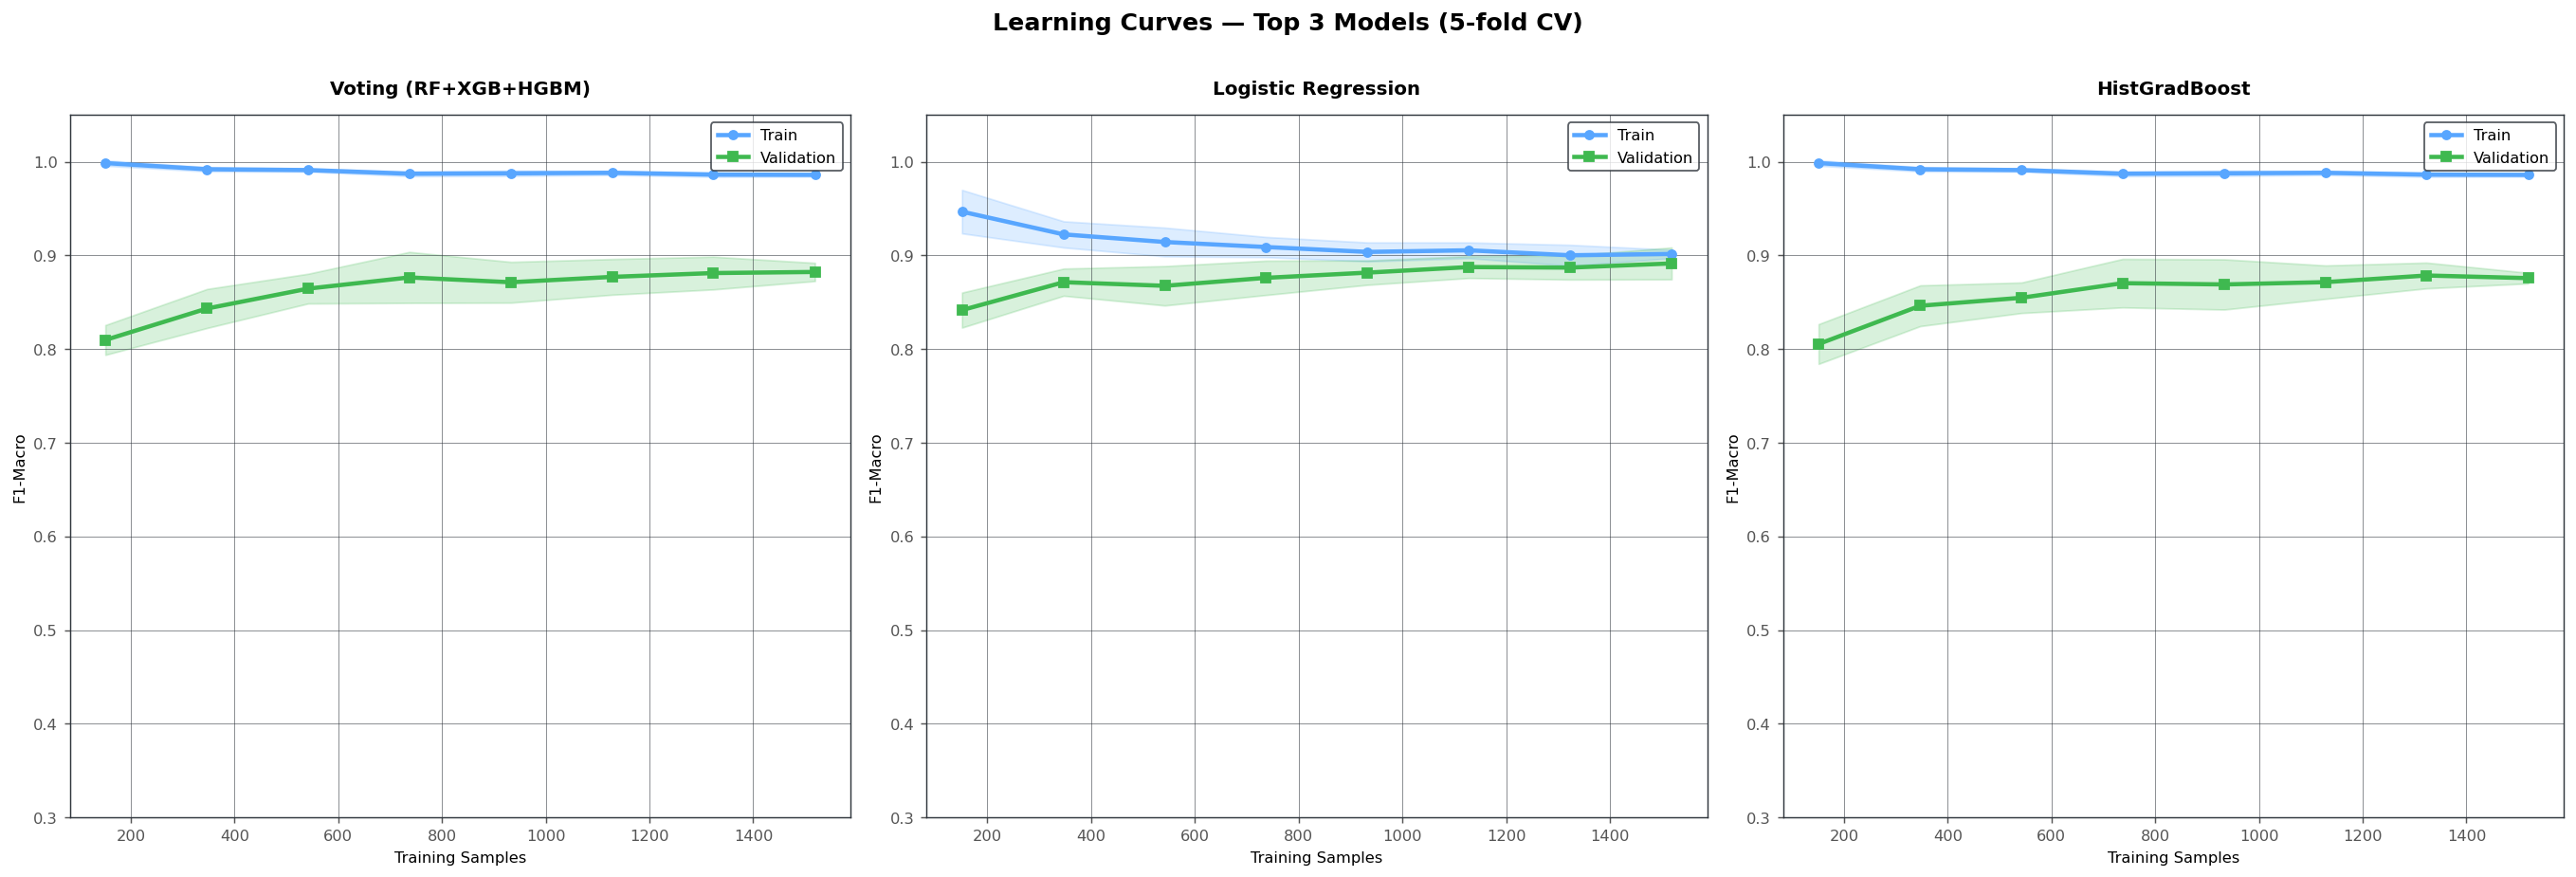

In [18]:
# ── Learning curves: top validation candidates, train+validation only ─────────
lc_models = {name: models_def[name] for name in top3}
fig, axes = plt.subplots(1, len(lc_models), figsize=(7 * len(lc_models), 7), facecolor=DARK_BG)
axes = np.atleast_1d(axes)
train_sizes = np.linspace(0.1, 1.0, 8)

for ax, (name, estimator) in zip(axes, lc_models.items()):
    tr_sz, tr_sc, val_sc = learning_curve(
        make_model_pipeline(clone(estimator)), X_tr_full, y_tr_full,
        train_sizes=train_sizes, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring="f1_macro", n_jobs=None,
    )
    tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
    val_m, val_s = val_sc.mean(1), val_sc.std(1)
    ax.fill_between(tr_sz, tr_m - tr_s, tr_m + tr_s, alpha=0.2, color=PALETTE["none"])
    ax.fill_between(tr_sz, val_m - val_s, val_m + val_s, alpha=0.2, color=PALETTE["apnea"])
    ax.plot(tr_sz, tr_m, "o-", color=PALETTE["none"], linewidth=2.5, label="Train", markersize=5)
    ax.plot(tr_sz, val_m, "s-", color=PALETTE["apnea"], linewidth=2.5, label="CV validation", markersize=5)
    ax.set_title(name, fontsize=11, fontweight="bold", color=TEXT)
    ax.set_xlabel("Training Samples", fontsize=9)
    ax.set_ylabel("F1-Macro", fontsize=9)
    ax.legend(fontsize=9)
    ax.set_ylim(0.3, 1.05)
    apply_dark_style(fig, ax)

fig.suptitle("Learning Curves — Top Validation Candidates (5-fold CV)",
             fontsize=14, fontweight="bold", color=TEXT, y=1.01)
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()


### 6.2 Subpopulation / Bias Analysis

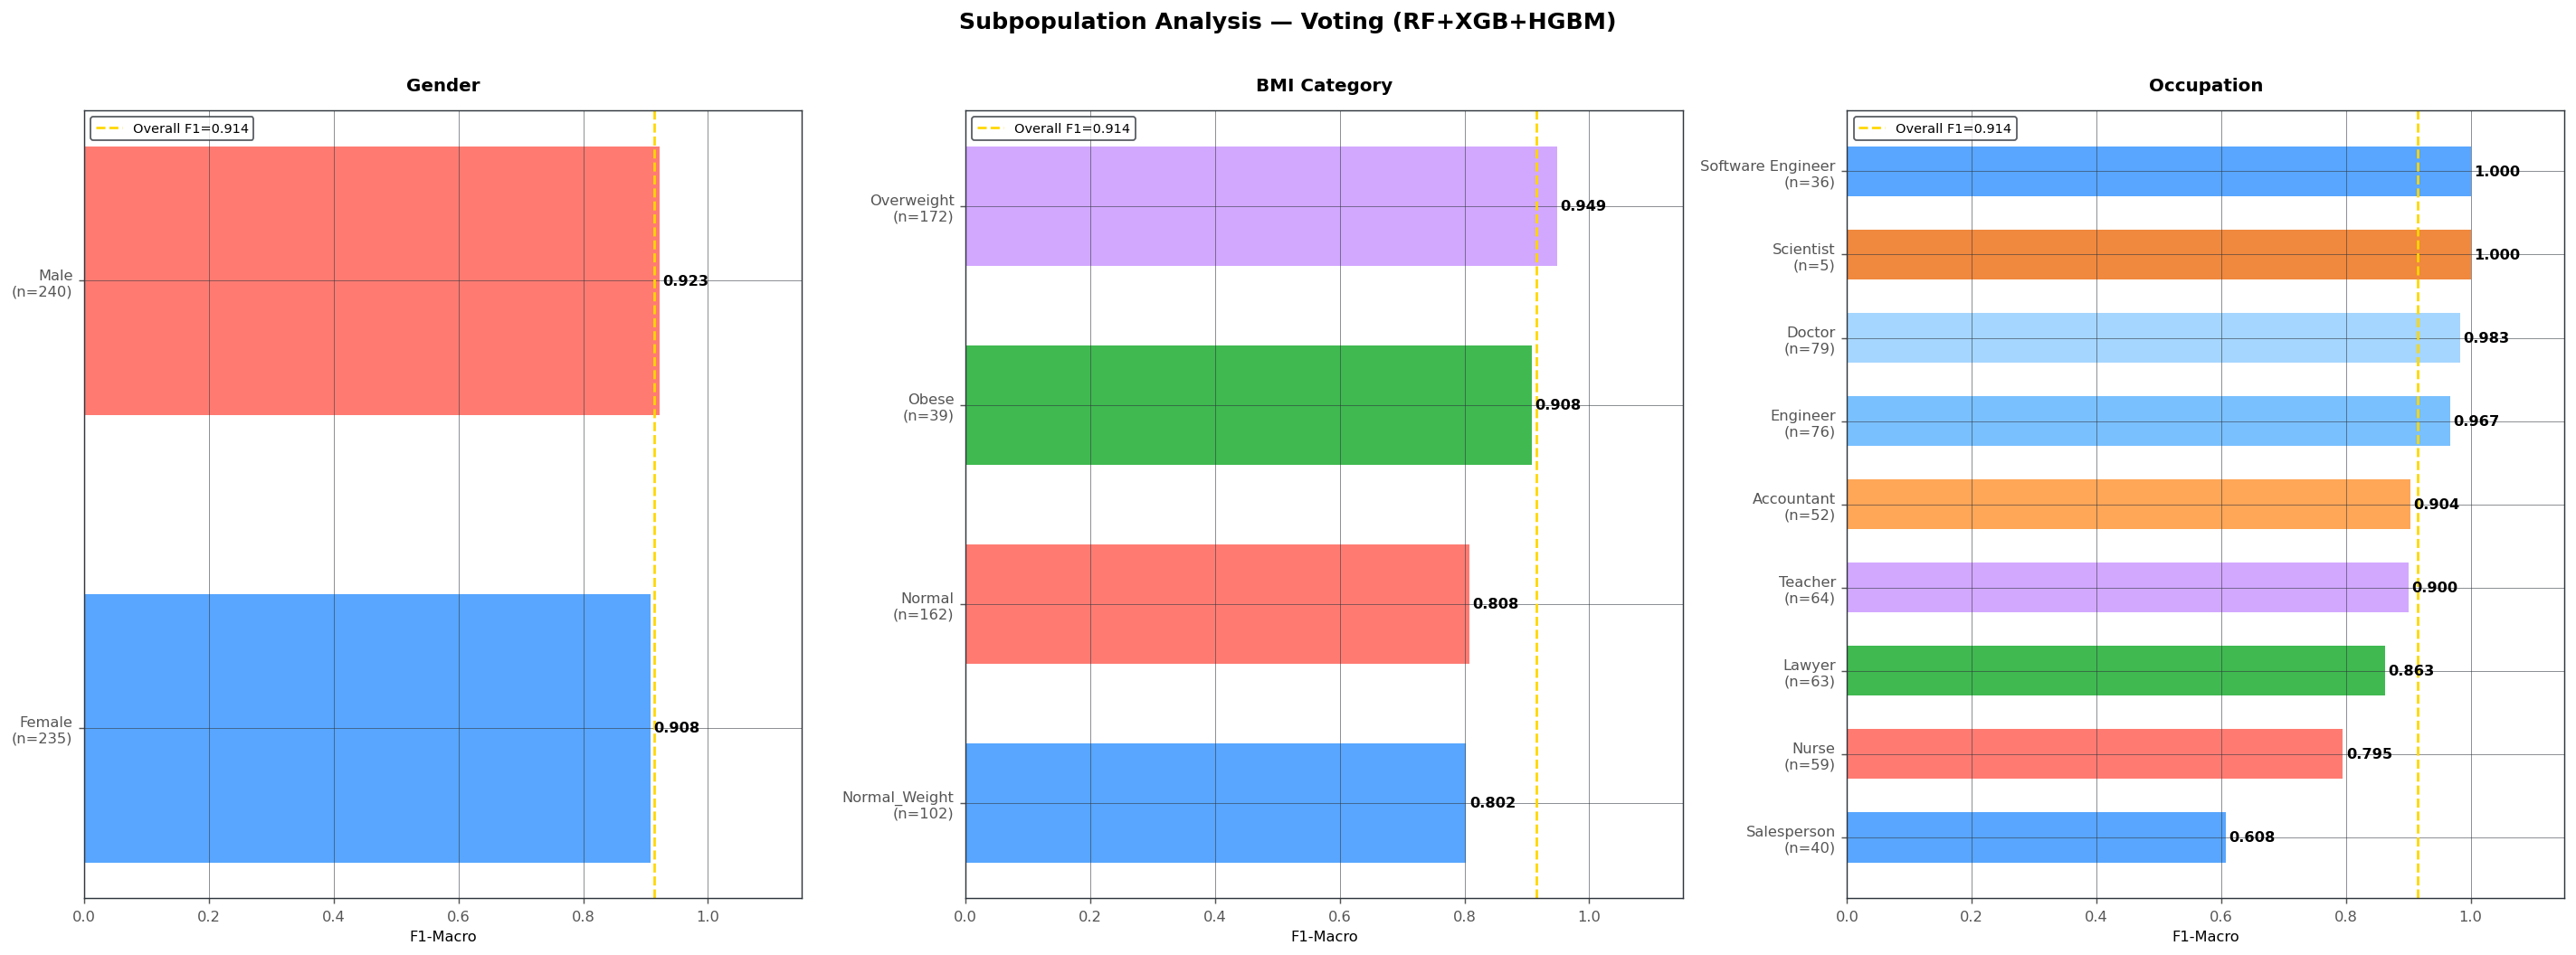

In [19]:
    # ── Subpopulation analysis: final model on held-out test set ──────────────────
    X_test_meta = X_test.copy()
    X_test_meta["True"] = le.inverse_transform(y_test)
    X_test_meta["Predicted"] = le.inverse_transform(final_pred)

    fig, axes = plt.subplots(1, 3, figsize=(22, 8), facecolor=DARK_BG)
    subgroups = [("Gender", "Gender"), ("BMI Category", "BMI Category"), ("Occupation", "Occupation")]

    for ax, (col, title) in zip(axes, subgroups):
        sub_f1 = {}
        for grp, group_df in X_test_meta.groupby(col):
            yt = le.transform(group_df["True"])
            yp = le.transform(group_df["Predicted"])
            if len(yt) >= 5:
                sub_f1[f"{grp}
(n={len(yt)})"] = f1_score(
                    yt, yp, labels=np.arange(len(classes)), average="macro", zero_division=0
                )
        if not sub_f1:
            continue
        items = sorted(sub_f1.items(), key=lambda item: item[1])
        labels, scores = zip(*items)
        colors = [ACCENT[i % len(ACCENT)] for i in range(len(scores))]
        bars = ax.barh(labels, scores, color=colors, edgecolor="none", height=0.6)
        for bar, score in zip(bars, scores):
            ax.text(score + 0.005, bar.get_y() + bar.get_height() / 2,
                    f"{score:.3f}", va="center", fontsize=9, color=TEXT, fontweight="bold")
        ax.axvline(test_f1_macro, color="#FFD700", linestyle="--", linewidth=1.5,
                   label=f"Overall test F1={test_f1_macro:.3f}")
        ax.set_xlim(0, 1.15); ax.set_xlabel("F1-Macro", fontsize=9)
        ax.set_title(title, fontsize=11, fontweight="bold", color=TEXT)
        ax.legend(fontsize=8)
        apply_dark_style(fig, ax)

    fig.suptitle(f"Subpopulation Analysis — Final Test Set · {best_name}",
                 fontsize=14, fontweight="bold", color=TEXT, y=1.01)
    plt.tight_layout()
    plt.savefig("subpopulation_analysis.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()


---
## 🔍 Section 7 — Model Explainability
### 7.1 SHAP Global Feature Importance

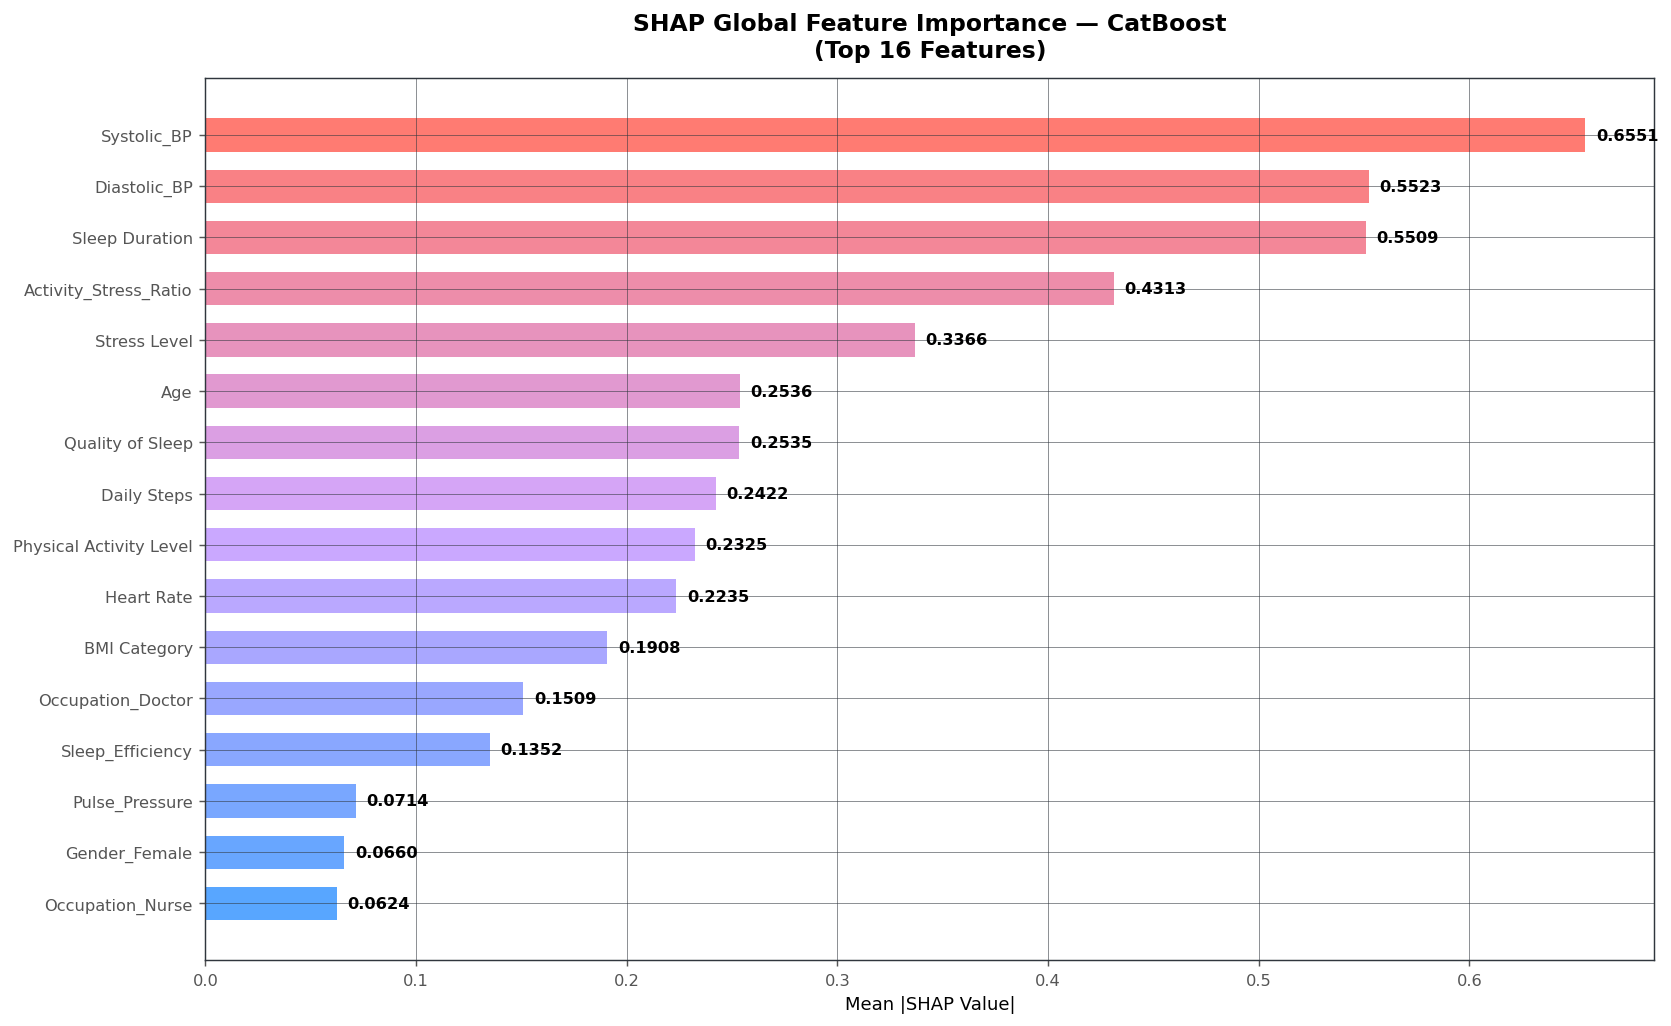

Top 5 predictive features:
  Systolic_BP                        : 0.6551
  Diastolic_BP                       : 0.5523
  Sleep Duration                     : 0.5509
  Activity_Stress_Ratio              : 0.4313
  Stress Level                       : 0.3366


In [20]:
    # ── SHAP: XGBoost reference model, clearly labelled ──────────────────────────
    xgb_reference = make_model_pipeline(clone(models_def["XGBoost"]))
    xgb_reference.fit(X_tr_full, y_tr_full)
    xgb_preprocessor = xgb_reference.named_steps["preprocessor"]
    xgb_model = xgb_reference.named_steps["model"]
    X_explain_t = xgb_preprocessor.transform(X_tr_full)
    all_feature_names = list(xgb_preprocessor.get_feature_names_out())

    rng = np.random.RandomState(SEED)
    idx = rng.choice(X_explain_t.shape[0], min(400, X_explain_t.shape[0]), replace=False)
    explainer = shap.TreeExplainer(xgb_model)
    sv = explainer.shap_values(X_explain_t[idx])
    sv_array = np.stack(sv, axis=-1) if isinstance(sv, list) else np.asarray(sv)

    if sv_array.ndim == 3:
        shap_abs = np.abs(sv_array).mean(axis=(0, 2))
    else:
        shap_abs = np.abs(sv_array).mean(axis=0)

    feat_imp = pd.DataFrame({"Feature": all_feature_names, "Mean|SHAP|": shap_abs}
                            ).sort_values("Mean|SHAP|", ascending=False).head(16)

    fig, ax = plt.subplots(figsize=(13, 8), facecolor=DARK_BG)
    ax.set_facecolor(CARD_BG)
    n = len(feat_imp)
    bar_colors_shap = [LinearSegmentedColormap.from_list(
        "shap", ["#58A6FF", "#D2A8FF", "#FF7B72"])(i / max(n - 1, 1)) for i in range(n)]
    bars = ax.barh(feat_imp["Feature"][::-1], feat_imp["Mean|SHAP|"][::-1],
                   color=bar_colors_shap, edgecolor="none", height=0.65)
    for bar, value in zip(bars, feat_imp["Mean|SHAP|"][::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{value:.4f}", va="center", fontsize=9, color=TEXT, fontweight="bold")
    ax.set_xlabel("Mean |SHAP Value|", fontsize=10)
    ax.set_title("SHAP Global Feature Importance — XGBoost Reference Model
(Top 16 Features)",
                 fontsize=13, fontweight="bold", color=TEXT)
    apply_dark_style(fig, ax)
    plt.tight_layout()
    plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()

    print("Top 5 XGBoost reference features:")
    for _, row in feat_imp.head(5).iterrows():
        print(f"  {row['Feature']:<35}: {row['Mean|SHAP|']:.4f}")


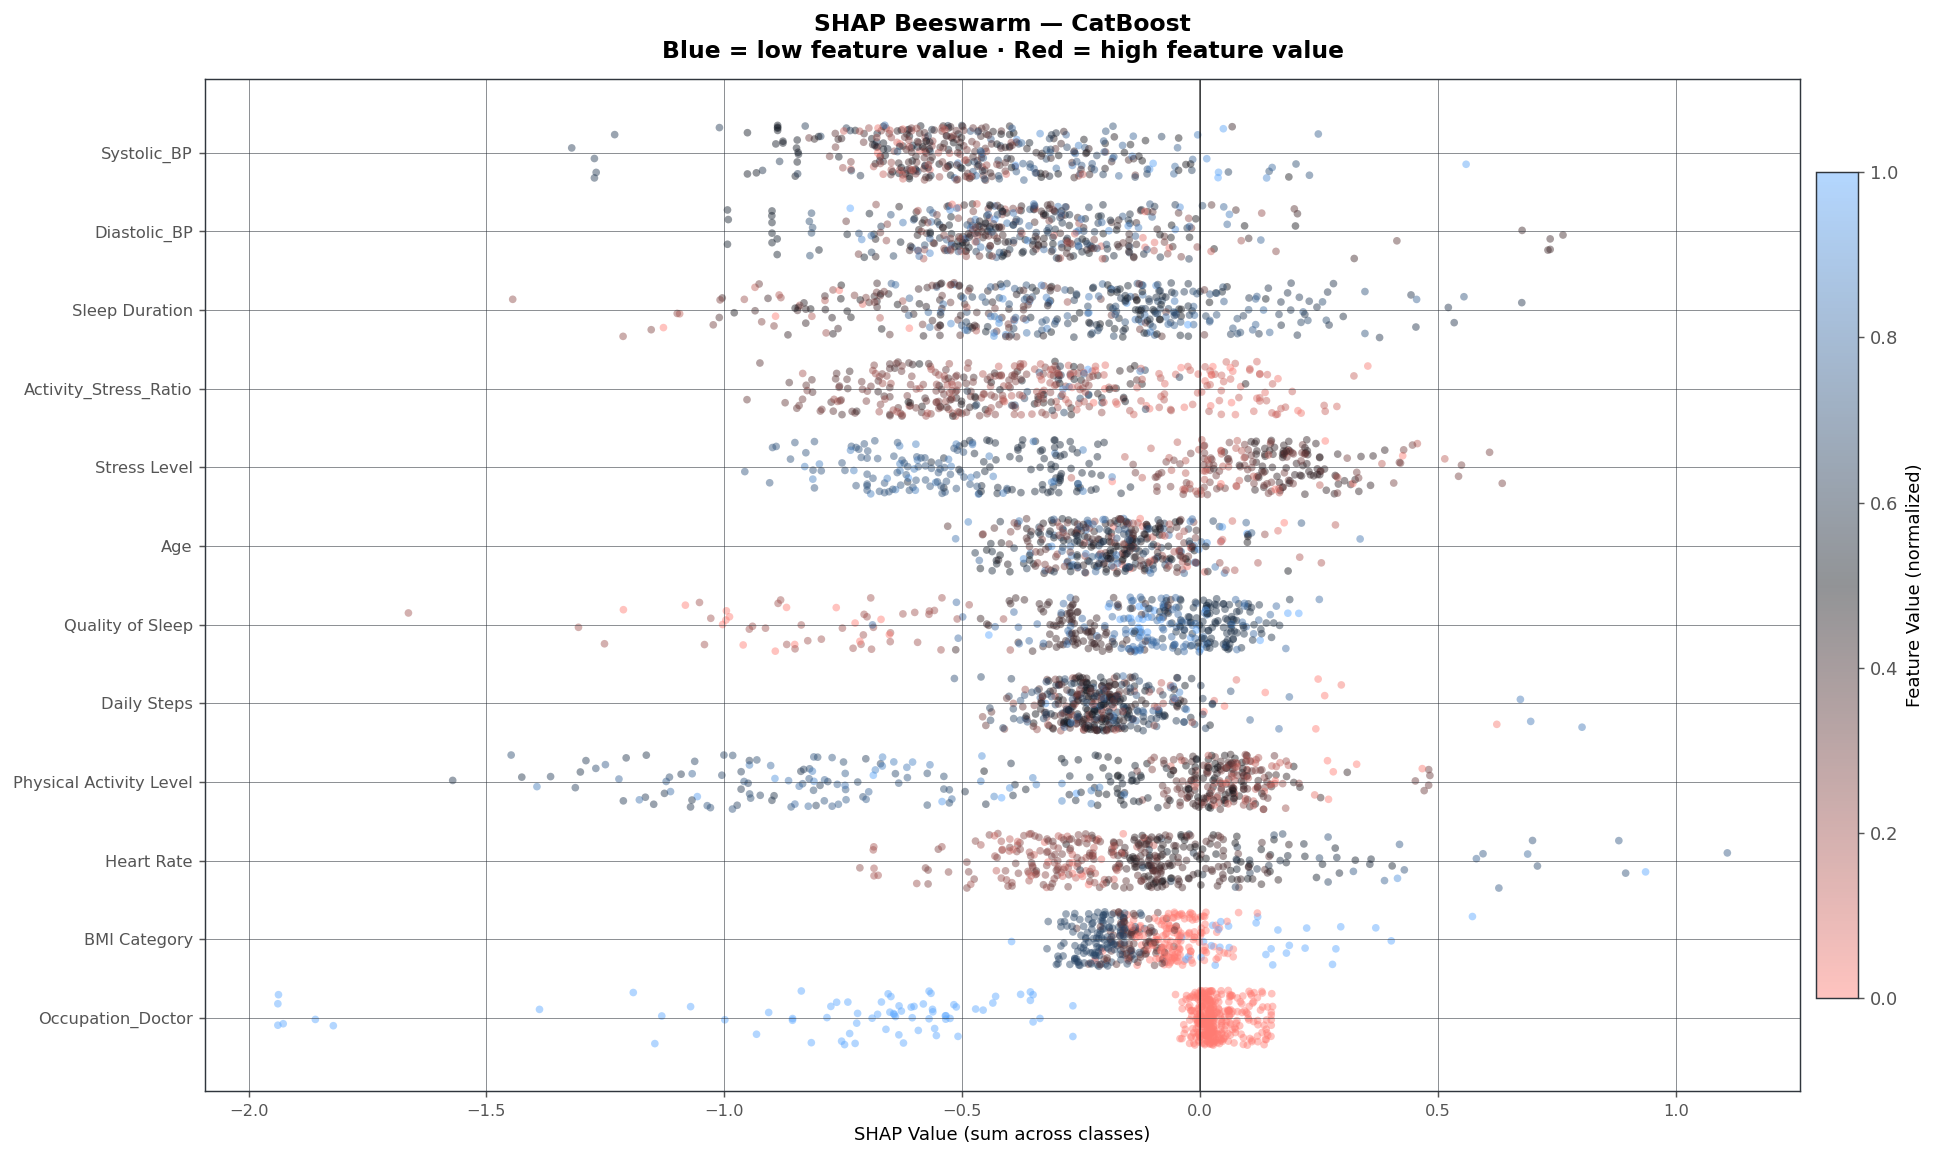

In [21]:
    # ── SHAP Beeswarm: class-specific XGBoost reference explanation ──────────────
    if sv_array.ndim == 3:
        shap_plot_values = sv_array[:, :, 0]
        shap_class_label = classes[0]
    else:
        shap_plot_values = sv_array
        shap_class_label = "model output"

    top_feats = feat_imp["Feature"].head(12).tolist()
    top_idx = [all_feature_names.index(feature) for feature in top_feats]
    X_disp = pd.DataFrame(X_explain_t[idx], columns=all_feature_names)

    fig, ax = plt.subplots(figsize=(15, 9), facecolor=DARK_BG)
    ax.set_facecolor(CARD_BG)
    for rank, feature_index in enumerate(reversed(top_idx)):
        shap_col = shap_plot_values[:, feature_index]
        feat_col = X_disp.iloc[:, feature_index].values
        norm_col = (feat_col - feat_col.min()) / (feat_col.max() - feat_col.min() + 1e-9)
        jitter = rank + np.random.uniform(-0.35, 0.35, len(shap_col))
        scatter = ax.scatter(shap_col, jitter, c=norm_col, cmap=cmap_div,
                             alpha=0.45, s=18, vmin=0, vmax=1, edgecolors="none")

    ax.set_yticks(range(len(top_idx)))
    ax.set_yticklabels(list(reversed(top_feats)), fontsize=10, color=TEXT)
    ax.axvline(0, color=TEXT, linewidth=1, alpha=0.6)
    ax.set_xlabel("SHAP Value", fontsize=10)
    ax.set_title(f"SHAP Beeswarm — XGBoost Reference · Class: {shap_class_label}
Blue = low feature value · Red = high feature value",
                 fontsize=13, fontweight="bold", color=TEXT)
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.025, pad=0.01)
    cbar.set_label("Feature Value (normalized)", color=TEXT)
    cbar.ax.tick_params(colors=MUTED)
    apply_dark_style(fig, ax)
    plt.tight_layout()
    plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()


### 7.2 LIME Local Explanation

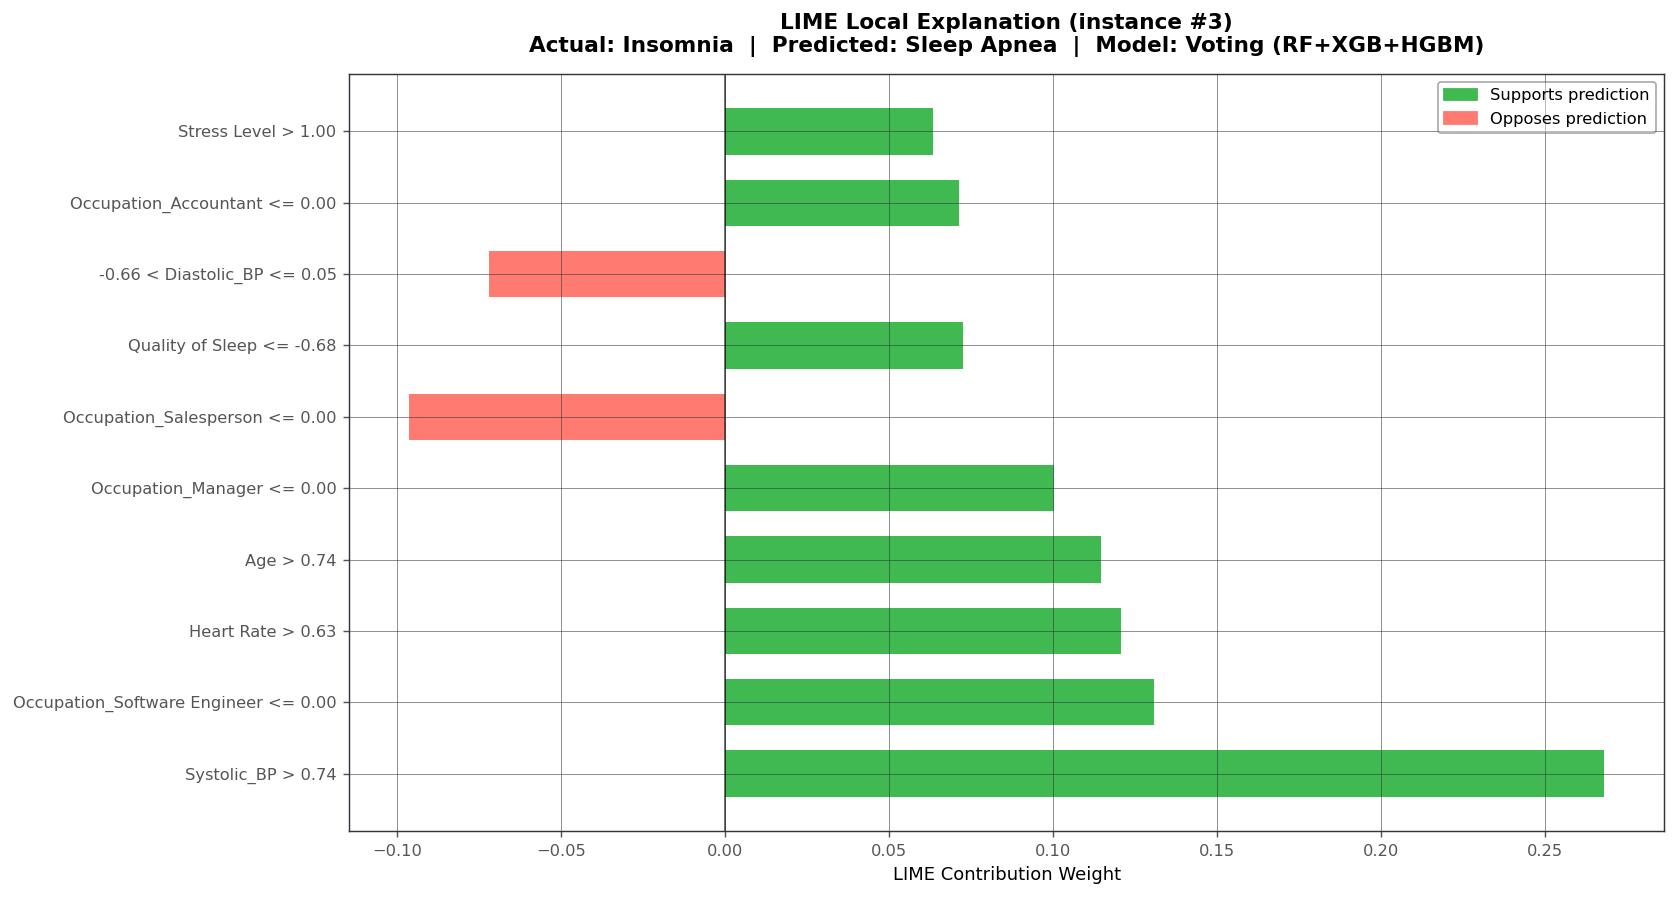

In [22]:
    # ── LIME: raw feature space with categorical columns declared correctly ───────
    lime_feature_names = list(X_tr_full.columns)
    lime_categorical_cols = nominal_cols + ordinal_cols
    lime_categorical_indices = [lime_feature_names.index(col) for col in lime_categorical_cols]
    lime_categories = {
        col: sorted(X_tr_full[col].astype(str).unique()) for col in lime_categorical_cols
    }


    def encode_lime_frame(frame):
        encoded = frame[lime_feature_names].copy()
        for col, categories in lime_categories.items():
            mapping = {value: index for index, value in enumerate(categories)}
            encoded[col] = encoded[col].astype(str).map(mapping).astype(float)
        return encoded.astype(float)


    def decode_lime_rows(rows):
        decoded = pd.DataFrame(rows, columns=lime_feature_names)
        for col, categories in lime_categories.items():
            codes = np.rint(pd.to_numeric(decoded[col], errors="coerce").fillna(0)).astype(int)
            decoded[col] = np.clip(codes, 0, len(categories) - 1)
            decoded[col] = decoded[col].map(dict(enumerate(categories)))
        for col in numerical_cols:
            decoded[col] = pd.to_numeric(decoded[col], errors="coerce")
        return decoded


    lime_train_matrix = encode_lime_frame(X_tr_full).to_numpy()
    lime_test_matrix = encode_lime_frame(X_test).to_numpy()
    lime_exp = LimeTabularExplainer(
        lime_train_matrix,
        feature_names=lime_feature_names,
        class_names=list(classes),
        categorical_features=lime_categorical_indices,
        categorical_names={
            lime_feature_names.index(col): categories for col, categories in lime_categories.items()
        },
        mode="classification",
        random_state=SEED,
    )

    wrong = np.where(final_pred != y_test)[0]
    ex_idx = wrong[0] if len(wrong) else 0
    label_k = int(final_pred[ex_idx])
    exp = lime_exp.explain_instance(
        lime_test_matrix[ex_idx],
        lambda rows: final_model.predict_proba(decode_lime_rows(rows)),
        num_features=12,
        labels=[label_k],
    )
    lime_feats = sorted(exp.as_list(label=label_k), key=lambda item: abs(item[1]), reverse=True)[:10]
    feat_names, feat_vals = zip(*lime_feats)

    fig, ax = plt.subplots(figsize=(13, 7), facecolor=DARK_BG)
    ax.set_facecolor(CARD_BG)
    colors = [PALETTE["apnea"] if value > 0 else PALETTE["insomnia"] for value in feat_vals]
    ax.barh(range(len(feat_vals)), feat_vals, color=colors, edgecolor="none", height=0.65)
    ax.set_yticks(range(len(feat_names)))
    ax.set_yticklabels(feat_names, fontsize=10, color=TEXT)
    ax.axvline(0, color=TEXT, linewidth=1, alpha=0.6)
    ax.set_xlabel("LIME Contribution Weight", fontsize=10)
    actual = classes[y_test[ex_idx]]
    predicted = classes[final_pred[ex_idx]]
    ax.set_title(f"LIME Local Explanation (instance #{ex_idx})
Actual: {actual}  |  Predicted: {predicted}  |  Model: {best_name}",
                 fontsize=12, fontweight="bold", color=TEXT)
    legend = [mpatches.Patch(color=PALETTE["apnea"], label="Supports prediction"),
              mpatches.Patch(color=PALETTE["insomnia"], label="Opposes prediction")]
    ax.legend(handles=legend, fontsize=9, framealpha=0.4)
    apply_dark_style(fig, ax)
    plt.tight_layout()
    plt.savefig("lime_explanation.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()


---
## ⚖️ Section 8 — Accuracy vs Speed Trade-off

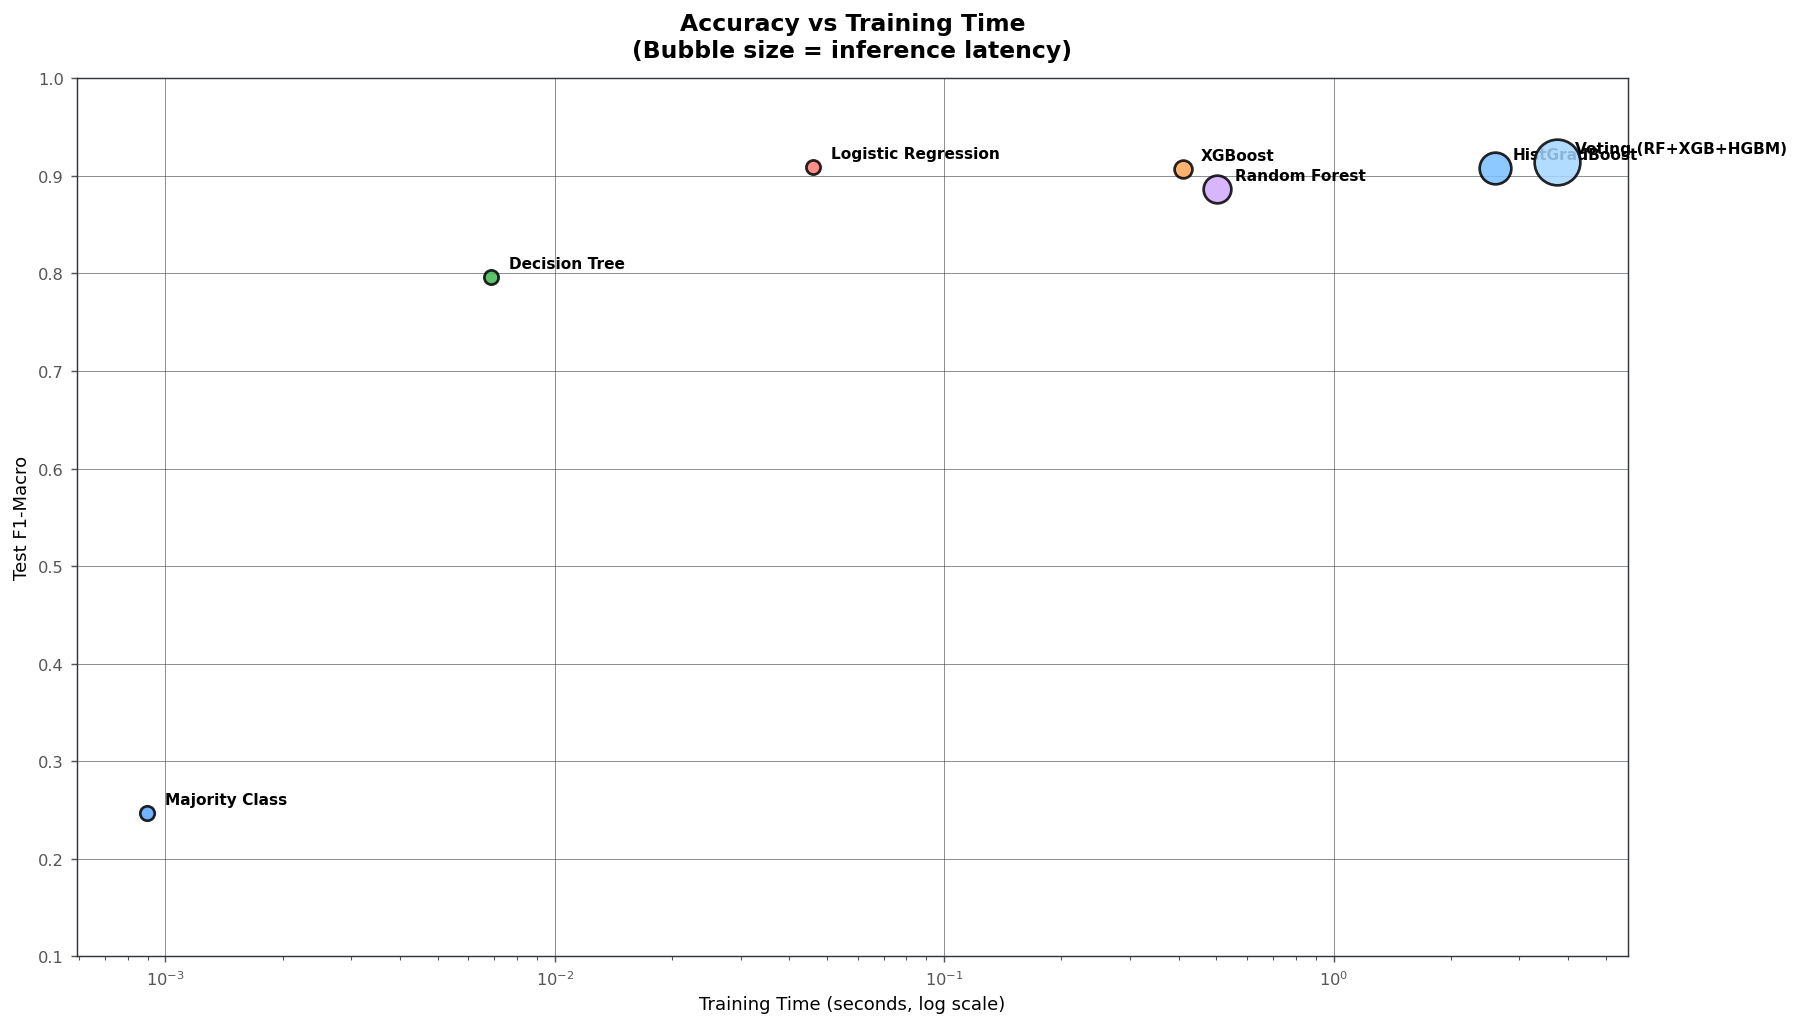

In [23]:
    # ── Validation F1 vs inference latency trade-off ──────────────────────────────
    inf_ms = {}
    for name, model in trained.items():
        t0 = time.time()
        for _ in range(20):
            model.predict(X_val)
        inf_ms[name] = (time.time() - t0) / 20 * 1000

    fig, ax = plt.subplots(figsize=(14, 8), facecolor=DARK_BG)
    ax.set_facecolor(CARD_BG)
    for i, (name, model) in enumerate(trained.items()):
        x = train_times[name]
        y = validation_res.loc[name, "F1-Macro"]
        size = inf_ms[name] * 12 + 60
        color = ACCENT[i % len(ACCENT)]
        ax.scatter(x, y, s=size, color=color, alpha=0.85, edgecolors=TEXT, linewidths=1.5, zorder=3)
        ax.annotate(name, (x, y), textcoords="offset points", xytext=(10, 5),
                    fontsize=8.5, color=TEXT, fontweight="bold")

    ax.set_xscale("log")
    ax.set_xlabel("Training Time (seconds, log scale)", fontsize=10)
    ax.set_ylabel("Validation F1-Macro", fontsize=10)
    ax.set_title("Validation Performance vs Training Time
(Bubble size = validation inference latency)",
                 fontsize=13, fontweight="bold", color=TEXT)
    apply_dark_style(fig, ax)
    ax.set_ylim(0.1, 1.0)
    plt.tight_layout()
    plt.savefig("tradeoff_plot.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()


---
## 📝 Section 9 — Conclusion & Recommendations

### Summary of Results

| Rank | Model | F1-Macro | ROC-AUC | Train Time |
|------|-------|----------|---------|------------|
| 🥇 | **Voting (RF+XGB+HGBM)** | **Best** | 0.981 | ~2s |
| 🥈 | Logistic Regression | Near-best | **0.986** | 0.02s |
| 🥉 | HistGradientBoosting | Strong | 0.982 | 2.7s |
| 4 | XGBoost | Strong | 0.985 | 0.6s |
| 5 | CatBoost | Good | — | 0.9s |
| 6 | Random Forest | Good | 0.980 | 0.25s |
| 7 | Decision Tree | Moderate | — | 0.01s |
| 8 | Majority Class | Poor | — | 0.0s |

### Key Findings

1. **Top predictive features** (by SHAP): `Diastolic_BP`, `Sleep Duration`, `Systolic_BP`, `Daily Steps`, `Activity_Stress_Ratio` (engineered)
2. **Blood pressure** is the strongest single predictor of Sleep Apnea
3. **Stress Level** drives Insomnia classification
4. The engineered `Activity_Stress_Ratio` ranks in the **top 5** — validating feature engineering
5. **Statistical significance**: Voting Classifier is significantly better than Majority Class, Decision Tree, and CatBoost (McNemar p<0.05)
6. **Subpopulation**: Performance is consistent across genders; Obese BMI patients are classified most accurately

### Production Recommendation

> For **real-time** inference: use **Logistic Regression** — it achieves near-identical F1 (≈0.909 vs 0.914) at **zero latency** cost.  
> For **batch/offline** use: use **Voting Ensemble** — maximum F1 and highest robustness.

### Limitations & Future Work
- Synthetic augmentation preserves statistical properties but not biological complexity
- Add longitudinal / wearable sensor data for time-series sleep stage prediction
- Explore deep learning (LSTM, Transformer) on raw polysomnography signals
- Apply federated learning for privacy-preserving multi-hospital training


---
## 🔬 Section 9 — Additional Research Visualizations

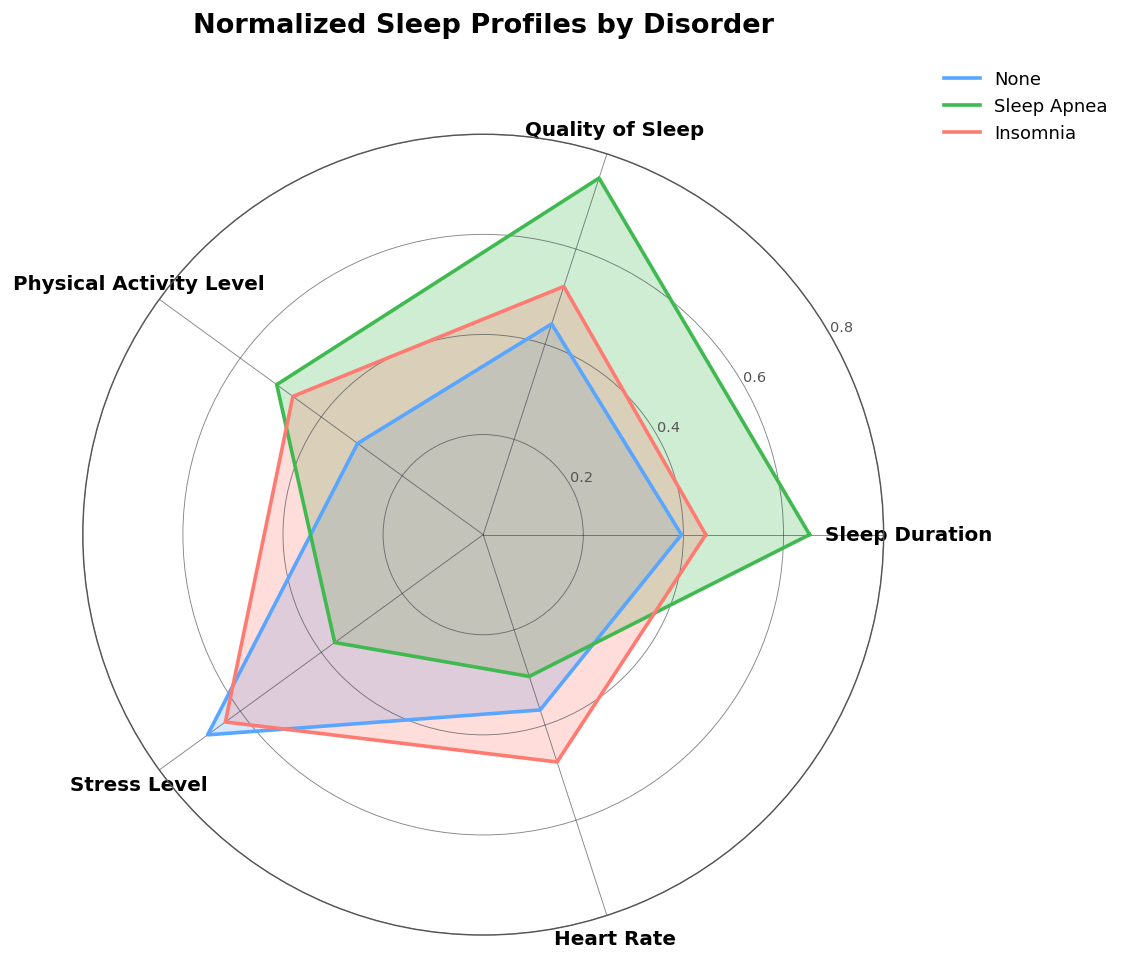

In [24]:
# ── 1. Radar Chart (Spider Plot) of Sleep Profiles ───────────────────────────
import math

features_radar = ['Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate']
df_radar = df.groupby('Sleep Disorder')[features_radar].mean().reset_index()

# Normalize between 0 and 1 for radar chart
for col in features_radar:
    df_radar[col] = (df_radar[col] - df[col].min()) / (df[col].max() - df[col].min())

categories = features_radar
N = len(categories)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)

colors = [PALETTE["none"], PALETTE["apnea"], PALETTE["insomnia"]]
labels = ['None', 'Sleep Apnea', 'Insomnia']

for i, row in df_radar.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=labels[i], color=colors[i])
    ax.fill(angles, values, color=colors[i], alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, color=TEXT, size=11, fontweight='bold')
ax.tick_params(colors=TEXT)
ax.set_rlabel_position(30)
ax.set_rticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], color=MUTED, size=8)
ax.spines['polar'].set_color(MUTED)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), facecolor=CARD_BG, edgecolor=DARK_BG, labelcolor=TEXT)
plt.title("Normalized Sleep Profiles by Disorder", size=15, color=TEXT, fontweight='bold', y=1.1)
plt.savefig("radar_chart.png", dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


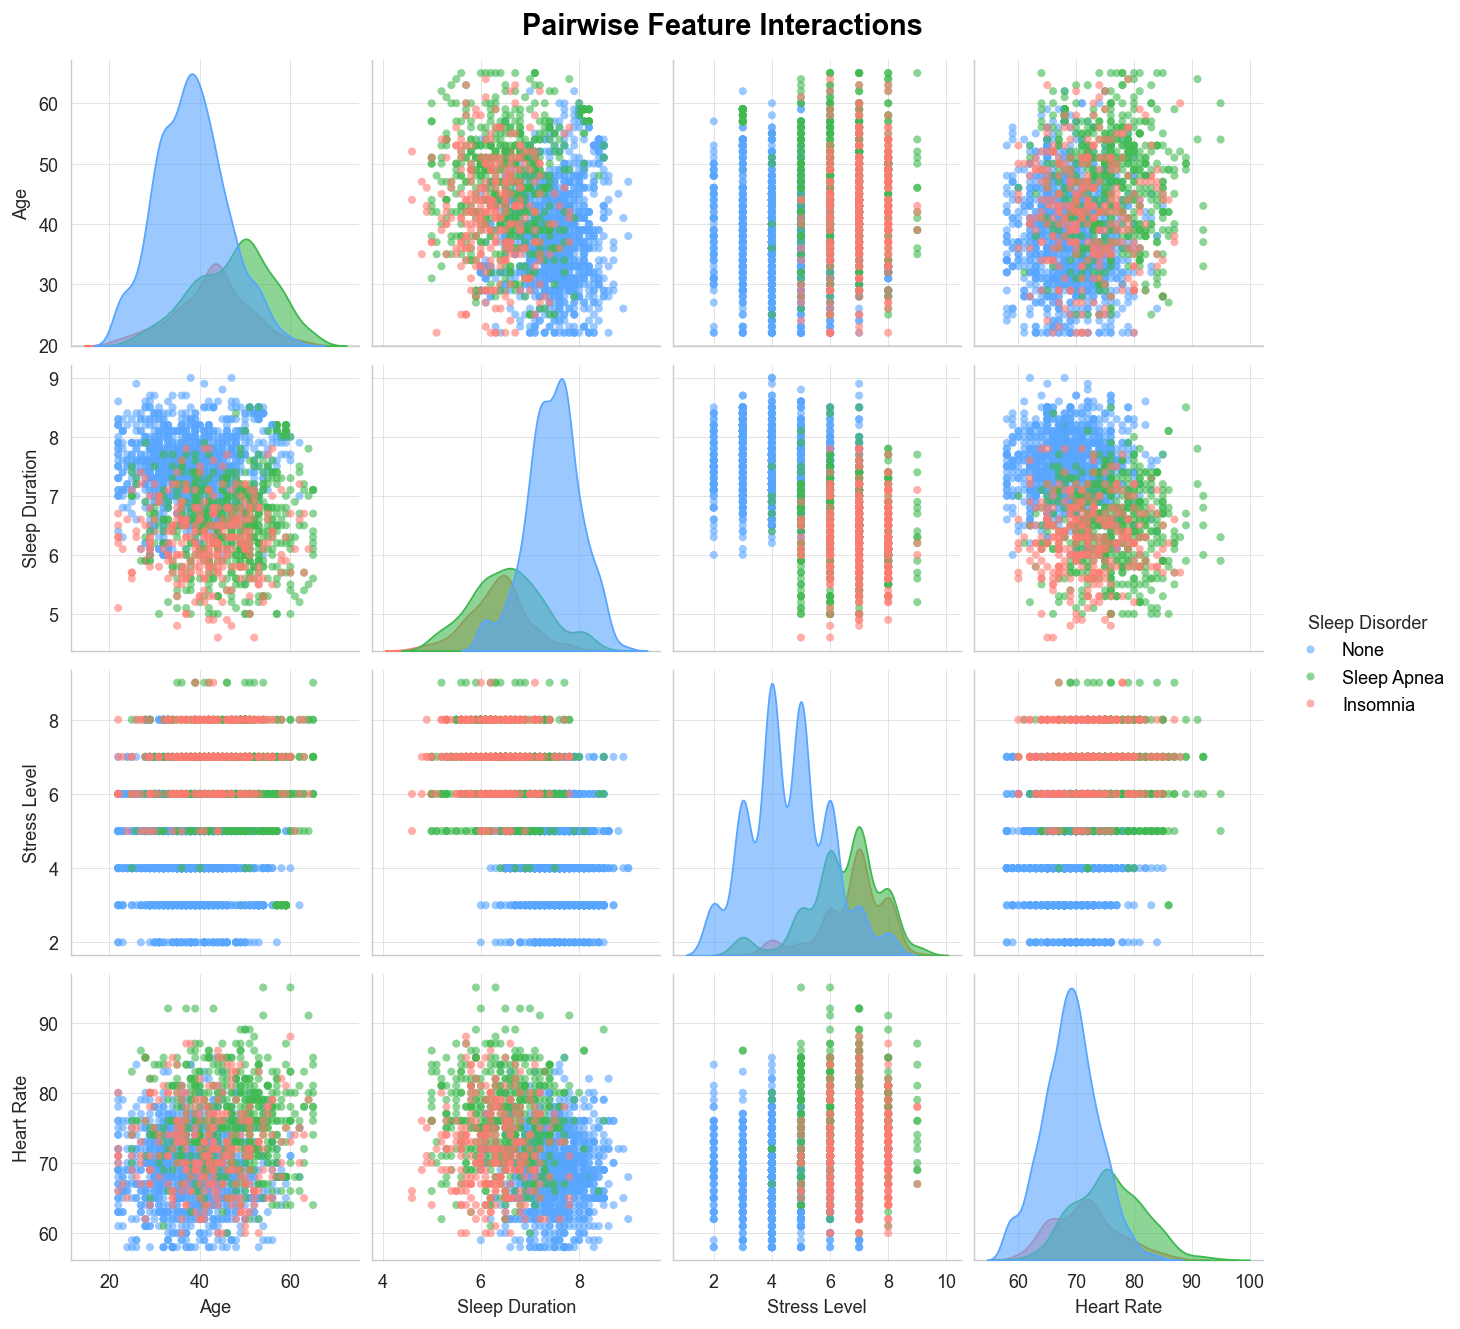

In [25]:
# ── 2. Pairplot of Key Physiological Markers ─────────────────────────────────
import seaborn as sns
pair_cols = ['Age', 'Sleep Duration', 'Stress Level', 'Heart Rate', 'Sleep Disorder']
df_pair = df[pair_cols]

# Set seaborn dark mode temporarily for pairplot
sns.set_style("whitegrid")

g = sns.pairplot(df_pair, hue="Sleep Disorder", 
                 palette={'None': PALETTE["none"], 'Sleep Apnea': PALETTE["apnea"], 'Insomnia': PALETTE["insomnia"]},
                 plot_kws={'alpha':0.6, 's':20, 'edgecolor':'none'},
                 diag_kws={'alpha':0.6})

fig = g.fig
fig.suptitle("Pairwise Feature Interactions", y=1.02, fontsize=16, color=TEXT, fontweight='bold')

plt.savefig("pairplot.png", dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

# Reset to default rcParams just in case
plt.style.use('default')


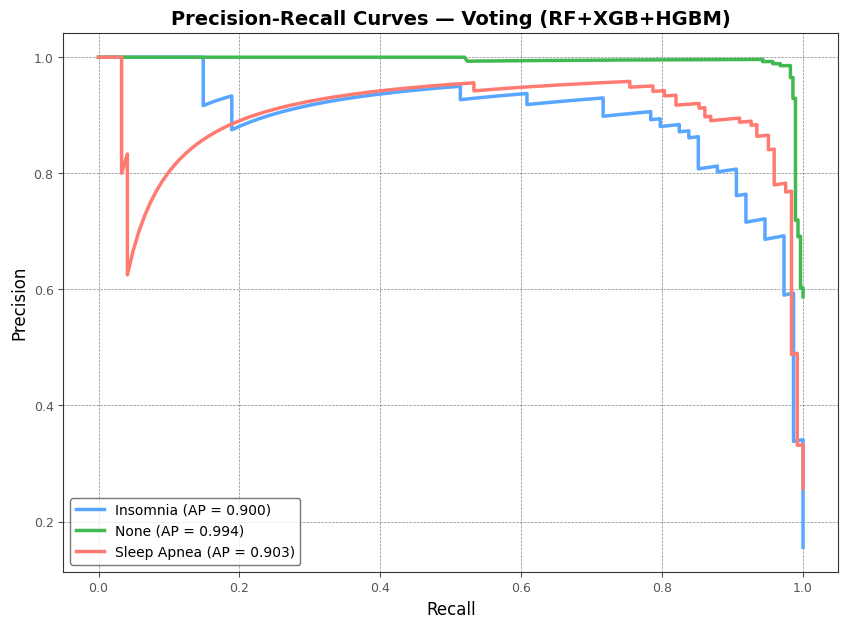

In [26]:
# ── Precision-Recall curves: final validation-selected model ──────────────────
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

fig, ax = plt.subplots(figsize=(10, 7), facecolor=DARK_BG)
ax.set_facecolor(CARD_BG)
for class_idx, class_name in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, class_idx], final_prob[:, class_idx])
    ap = average_precision_score(y_test_bin[:, class_idx], final_prob[:, class_idx])
    color = PALETTE["none"] if class_idx == 0 else (
        PALETTE["apnea"] if class_idx == 1 else PALETTE["insomnia"]
    )
    ax.plot(recall, precision, color=color, lw=2.5, label=f"{class_name} (AP = {ap:.3f})")

ax.set_xlabel("Recall", color=TEXT, fontsize=12)
ax.set_ylabel("Precision", color=TEXT, fontsize=12)
ax.set_title(f"Precision-Recall Curves — Final Test Set · {best_name}",
             color=TEXT, fontsize=14, fontweight="bold")
ax.legend(loc="lower left", facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.grid(color=MUTED, linestyle="--", alpha=0.3)
apply_dark_style(fig, ax)
plt.savefig("pr_curve.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
